<a href="https://colab.research.google.com/github/mtalafha90/CNN_CPC/blob/main/notebook/knee_mri_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standalone high-resolution sparse-MIL knee MRI training

This is a self-contained Google Colab notebook for a small MRI subset on
Google Drive. It creates a new model directly from the CSV labels and DICOM
images in that folder. Every data utility, class, loss, training function, and
visualization function is defined below and annotated for study.

The image path is:

```text
DICOM volume
→ percentile normalisation
→ 32 deterministic 2.5D triplets per MRI series
→ native 90% centre crop
→ one antialiased 448×448 resize
→ 6×6 local feature grid
→ target-specific top-k sparse multiple-instance pooling
```

The default configuration is deliberately conservative for a small Colab GPU:
one study per batch, no loader workers, no pinned host memory, and no more than
six MRI series per study. The notebook includes a no-update preflight before
training, a loss plot, and a review of 12 classified cases.

## 1. Google Drive layout

Keep the two supplied archives at the top level of Google Drive. The notebook
mounts Drive, copies them to Colab's fast local disk, safely unzips them, and
then automatically finds the training and test folders regardless of a single
top-level folder inside either archive.

```text
MyDrive/
├── colab_subset.zip                 # training CSVs and training DICOM subset
├── test.zip                         # test CSVs and test DICOM subset
└── knee_mri_subset_outputs/         # created by this notebook
```

Expected extracted training layout: `train.csv`, `train_series.csv`, and either
`train_series/` or `train_images/`. Expected extracted test layout: `test.csv`,
`test_series.csv`, and either `test_series/` or `test_images/`.

- `train.csv` needs `StudyInstanceUID` and the 12 target columns listed below.
  A target cell can be `0`, `1`, or blank; blank labels are ignored by the loss.
- `train_series.csv` needs `StudyInstanceUID`, `SeriesInstanceUID`,
  `Fluid_Sensitive`, `Fat_Suppression`, and `Anatomical_Plane`.
- The test subset is used after training to produce `test_predictions.csv` with
  the 12 probability columns and thresholded classifications.

## 2. Install the DICOM reader

In [1]:
# Import Python's package installer helper.
import sys
# Import the process runner used to install the missing package.
import subprocess

# Install pydicom because Colab does not guarantee that it is preinstalled.
subprocess.run(
    # Use the current notebook Python interpreter for a compatible installation.
    [sys.executable, "-m", "pip", "install", "-q", "pydicom>=2.4"],
    # Stop this cell immediately if installation fails.
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'pydicom>=2.4'], returncode=0)

## 3. Imports, labels, and reproducibility

In [2]:
# Enable modern type annotations in every definition in this cell.
from __future__ import annotations

# Import dataclass helpers for clear configuration and experiment containers.
from dataclasses import asdict, dataclass, field
# Import a no-op context manager for CPU execution.
from contextlib import nullcontext
# Import Path for safe cross-platform file paths.
from pathlib import Path
# Import type names used in function annotations.
from typing import Iterable
# Import garbage collection for releasing large CPU tensors between epochs.
import gc
# Import JSON for readable configuration and history files.
import json
# Import math for sine/cosine position features and log-mean-exp pooling.
import math
# Import random for reproducible Python-level sampling.
import random
# Import shutil for copying the two Drive archives to Colab's local SSD.
import shutil
# Import time for per-epoch timing.
import time
# Import zipfile for safe archive inspection and extraction.
import zipfile

# Import matplotlib for the loss curve and case-review figures.
import matplotlib.pyplot as plt
# Import NumPy for numerical arrays and deterministic splitting.
import numpy as np
# Import pandas for CSV tables and summary tables.
import pandas as pd
# Import PyTorch's main namespace.
import torch
# Import neural-network layers and functional operations.
import torch.nn.functional as F
from torch import nn
# Import the dataset and loader interfaces.
from torch.utils.data import DataLoader, Dataset
# Import display so summary tables render in Colab.
from IPython.display import display

# List target columns exactly as they appear in train.csv.
TARGETS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture",
]
# Store the target count once so model classes do not repeat a magic number.
N_TARGETS = len(TARGETS)
# Convert normalized plane names into small categorical identifiers.
PLANE_TO_ID = {"Sagittal": 1, "Coronal": 2, "Axial": 3}


def set_seed(seed: int = 2026) -> None:
    """Make splitting and new-model initialization reproducible."""
    # Seed Python's random-number generator.
    random.seed(seed)
    # Seed NumPy's random-number generator.
    np.random.seed(seed)
    # Seed CPU PyTorch operations.
    torch.manual_seed(seed)
    # Seed every visible CUDA device when a GPU is present.
    torch.cuda.manual_seed_all(seed)
    # Prefer repeatability over cuDNN auto-tuned speed.
    torch.backends.cudnn.benchmark = False
    # Request deterministic cuDNN kernels when available.
    torch.backends.cudnn.deterministic = True


# Set the notebook-wide seed before creating any model or split.
set_seed()
# Choose the GPU if Colab provides one; otherwise keep the notebook functional on CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Print the selected device for a quick environment check.
print("device:", DEVICE)
# Print the concrete GPU name when CUDA is available.
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


## 4. Mount Drive, copy both archives locally, and define the run configuration

In [3]:
def mount_drive(mount_point: str = "/content/drive") -> Path:
    """Mount Google Drive and return the mounted root directory."""
    # Import Colab's Drive helper only inside this Colab-specific function.
    from google.colab import drive
    # Ask Colab to mount the authenticated user's Drive at the requested location.
    drive.mount(mount_point)
    # Return a Path object so later cells use safe path joins.
    return Path(mount_point)


@dataclass(frozen=True)
class ArchivePaths:
    """Locations of the two Drive archives and their fast local extraction folder."""

    # Hold the archive containing train.csv, train_series.csv, and training DICOM files.
    training_archive: Path
    # Hold the archive containing test.csv, test_series.csv, and test DICOM files.
    test_archive: Path
    # Hold the Colab-local folder used while reading large DICOM files.
    local_root: Path


def safe_extract_zip(archive: Path, destination: Path) -> None:
    """Extract one ZIP archive while refusing paths that escape the destination folder."""
    # Create the local destination if this is the first notebook run.
    destination.mkdir(parents=True, exist_ok=True)
    # Resolve the destination once for reliable ZIP member safety checks.
    resolved_destination = destination.resolve()
    # Open the archive for a read-only member inspection and extraction.
    with zipfile.ZipFile(archive) as zip_file:
        # Check every archived filename before writing any file.
        for member in zip_file.infolist():
            # Resolve the output path implied by this archive member.
            target = (destination / member.filename).resolve()
            # Reject an archive member that would write outside the intended folder.
            if target != resolved_destination and resolved_destination not in target.parents:
                raise RuntimeError(f"Unsafe ZIP path in {archive.name}: {member.filename}")
        # Extract all verified files into Colab's local SSD-backed storage.
        zip_file.extractall(destination)


def copy_and_extract_archives(archives: ArchivePaths) -> Path:
    """Copy Drive ZIP files to local storage, then unpack both before any DICOM reading."""
    # Create the local root without deleting an earlier extraction.
    archives.local_root.mkdir(parents=True, exist_ok=True)
    # Process training and test archives in a fixed, readable order.
    for source_archive in (archives.training_archive, archives.test_archive):
        # Stop with the exact missing Drive filename if an archive is not present.
        if not source_archive.is_file():
            raise FileNotFoundError(f"Missing Drive archive: {source_archive}")
        # Put a local copy beside the extracted data using the original filename.
        local_archive = archives.local_root / source_archive.name
        # Copy once from Drive so later DICOM reads avoid the slower mounted filesystem.
        shutil.copy2(source_archive, local_archive)
        # Extract the locally copied archive into the same local root.
        safe_extract_zip(local_archive, archives.local_root)
        # Report the completed copy/extract step.
        print(f"Ready: {source_archive.name} -> {archives.local_root}")
    # Return the local root used by the next path-discovery functions.
    return archives.local_root


def find_extracted_root(local_root: Path, table_name: str, series_table_name: str) -> Path:
    """Find exactly one extracted data root containing both required CSV tables."""
    # Find every parent folder that contains the requested study-level table.
    candidates = [
        path.parent
        for path in local_root.rglob(table_name)
        if (path.parent / series_table_name).is_file()
    ]
    # Stop when archives did not extract the expected pair of tables.
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {table_name} and {series_table_name} below {local_root}"
        )
    # Stop rather than guessing if archives contain more than one matching dataset folder.
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one folder with {table_name} and {series_table_name}; found {candidates}"
        )
    # Return the unambiguous extracted dataset folder.
    return candidates[0]


@dataclass(frozen=True)
class DrivePaths:
    """Locations for local training data and persistent Drive outputs."""

    # Hold the local folder containing train.csv, train_series.csv, and training DICOM files.
    data_root: Path
    # Hold the Drive folder where this notebook writes persistent new results.
    output_root: Path

    @property
    def train_csv(self) -> Path:
        """Return the path of the study-level CSV file."""
        # Join the dataset root and the fixed study-table filename.
        return self.data_root / "train.csv"

    @property
    def series_csv(self) -> Path:
        """Return the path of the series-level CSV file."""
        # Join the dataset root and the fixed series-table filename.
        return self.data_root / "train_series.csv"


def make_paths(dataset_root: str | Path, output_root: str | Path | None = None) -> DrivePaths:
    """Build training-data and output paths from extracted local data and an optional Drive output folder."""
    # Convert either a string or Path into a Path object.
    root = Path(dataset_root)
    # Use a local outputs folder only when no persistent Drive output folder was supplied.
    results = root / "outputs" if output_root is None else Path(output_root)
    # Return the complete training input and output path bundle.
    return DrivePaths(data_root=root, output_root=results)


@dataclass(frozen=True)
class TestPaths:
    """Locations for the separately extracted test subset."""

    # Hold the local folder containing test.csv, test_series.csv, and test DICOM files.
    data_root: Path

    @property
    def test_csv(self) -> Path:
        """Return the test study table path."""
        # Join the test root and fixed test-table filename.
        return self.data_root / "test.csv"

    @property
    def series_csv(self) -> Path:
        """Return the test series metadata table path."""
        # Join the test root and fixed test-series table filename.
        return self.data_root / "test_series.csv"


def make_test_paths(dataset_root: str | Path) -> TestPaths:
    """Build test-subset paths from the extracted local folder."""
    # Convert either a string or Path into a Path object.
    root = Path(dataset_root)
    # Return the complete test input path bundle.
    return TestPaths(data_root=root)


@dataclass(frozen=True)
class RunConfig:
    """All user-adjustable choices for one standalone training run."""

    # Keep the high-resolution in-plane representation.
    image_size: int = 448
    # Use 32 deterministic slice centers per MRI series.
    slices_per_series: int = 32
    # Use immediate neighbors as the other two 2.5D channels.
    triplet_gap: int = 1
    # Retain the central 90 percent of each native-resolution image.
    crop_fraction: float = 0.90
    # Pool local encoder features into a 6 by 6 evidence grid.
    grid_size: int = 6
    # Retain the top eight local evidence tokens for every target.
    top_k: int = 8
    # Use a compact 128-dimensional model for practical Colab memory use.
    feature_dim: int = 128
    # Encode two 448-pixel triplets at a time to limit GPU activation memory.
    encoder_chunk_size: int = 2
    # Keep six series by default; set zero only after a larger preflight passes.
    max_series_per_study: int = 6
    # Keep one study per batch to avoid padding and duplicate CPU allocations.
    batch_size: int = 1
    # Decode in the main process so worker processes cannot multiply host RAM use.
    num_workers: int = 0
    # Reserve twenty percent of usable labelled studies for validation.
    validation_fraction: float = 0.20
    # Run three epochs by default for a small-subset smoke run.
    epochs: int = 3
    # Set the AdamW learning rate.
    learning_rate: float = 1e-4
    # Set the AdamW weight decay.
    weight_decay: float = 1e-4
    # Give the sparse local classifier a direct auxiliary loss.
    local_loss_weight: float = 1.0
    # Limit one optimizer update's gradient norm.
    grad_clip_norm: float = 1.0
    # Save the split and initialization randomness with this seed.
    seed: int = 2026
    # Raise on a bad DICOM when true; otherwise skip just that unreadable series.
    strict_dicom: bool = False


# Mount the user's Google Drive once for this notebook session.
DRIVE_ROOT = mount_drive()
# Declare the two archive names supplied by the user and the fast local extraction folder.
ARCHIVES = ArchivePaths(
    training_archive=DRIVE_ROOT / "MyDrive" / "colab_subset.zip",
    test_archive=DRIVE_ROOT / "MyDrive" / "test.zip",
    local_root=Path("/content/knee_mri_subset"),
)
# Copy and unpack both archives before any training or test DICOM read.
LOCAL_ROOT = copy_and_extract_archives(ARCHIVES)
# Find the extracted training root without assuming how the ZIP file nests its top folder.
TRAINING_ROOT = find_extracted_root(LOCAL_ROOT, "train.csv", "train_series.csv")
# Find the extracted test root without assuming how the ZIP file nests its top folder.
TEST_ROOT = find_extracted_root(LOCAL_ROOT, "test.csv", "test_series.csv")
# Read high-volume training images from local storage and save results persistently to Drive.
PATHS = make_paths(TRAINING_ROOT, DRIVE_ROOT / "MyDrive" / "knee_mri_subset_outputs")
# Read high-volume test images from local storage.
TEST_PATHS = make_test_paths(TEST_ROOT)
# Create the default conservative training configuration.
CONFIG = RunConfig()
# Display the resolved training paths for confirmation.
print(PATHS)
# Display the resolved test paths for confirmation.
print(TEST_PATHS)
# Display all active model and memory settings for confirmation.
print(CONFIG)

Mounted at /content/drive
Ready: colab_subset.zip -> /content/knee_mri_subset
Ready: test.zip -> /content/knee_mri_subset
DrivePaths(data_root=PosixPath('/content/knee_mri_subset/colab_subset'), output_root=PosixPath('/content/drive/MyDrive/knee_mri_subset_outputs'))
TestPaths(data_root=PosixPath('/content/knee_mri_subset'))
RunConfig(image_size=448, slices_per_series=32, triplet_gap=1, crop_fraction=0.9, grid_size=6, top_k=8, feature_dim=128, encoder_chunk_size=2, max_series_per_study=6, batch_size=1, num_workers=0, validation_fraction=0.2, epochs=3, learning_rate=0.0001, weight_decay=0.0001, local_loss_weight=1.0, grad_clip_norm=1.0, seed=2026, strict_dicom=False)


## 5. Validate the tables and create the MRI series index

In [4]:
# Define accepted text values that mean true in the metadata table.
TRUE_TOKENS = {"true", "t", "yes", "y", "1", "1.0"}
# Define accepted text values that mean false in the metadata table.
FALSE_TOKENS = {"false", "f", "no", "n", "0", "0.0"}


def parse_bool(value: object) -> int:
    """Convert a metadata flag to 0 unknown, 1 false, or 2 true."""
    # Preserve missing metadata as the unknown code.
    if pd.isna(value):
        return 0
    # Convert Python and NumPy booleans directly.
    if isinstance(value, (bool, np.bool_)):
        return 2 if bool(value) else 1
    # Convert numeric nonzero values into true and zero values into false.
    if isinstance(value, (int, float, np.integer, np.floating)):
        return 2 if float(value) != 0 else 1
    # Normalize text before checking the accepted tokens.
    text = str(value).strip().lower()
    # Map accepted true tokens to code two.
    if text in TRUE_TOKENS:
        return 2
    # Map accepted false tokens to code one.
    if text in FALSE_TOKENS:
        return 1
    # Treat all other values as unknown.
    return 0


def normalise_plane(value: object) -> str:
    """Map common plane spelling variants to a standard anatomical-plane name."""
    # Define the accepted spelling variants.
    mapping = {
        "sagittal": "Sagittal", "sag": "Sagittal", "sagital": "Sagittal",
        "coronal": "Coronal", "cor": "Coronal",
        "axial": "Axial", "ax": "Axial", "transverse": "Axial",
    }
    # Return an empty string for a plane that cannot be recognized safely.
    return mapping.get(str(value).strip().lower(), "")


def validate_dataset(paths: DrivePaths) -> dict:
    """Validate the local training CSV schema and DICOM layout before using the GPU."""
    # List the two CSV files required by the standalone workflow.
    required_files = (paths.train_csv, paths.series_csv)
    # Collect every missing CSV filename so one error explains the whole problem.
    missing_files = [str(path) for path in required_files if not path.is_file()]
    # Stop before loading data if a required file is absent.
    if missing_files:
        raise FileNotFoundError("Missing required file(s):\n" + "\n".join(missing_files))
    # Load the study-level table.
    train = pd.read_csv(paths.train_csv)
    # Load the series-level table.
    series = pd.read_csv(paths.series_csv)
    # Require a study UID and every classification target in the study table.
    train_required = {"StudyInstanceUID", *TARGETS}
    # Require series identifiers and routing metadata in the series table.
    series_required = {
        "StudyInstanceUID", "SeriesInstanceUID", "Fluid_Sensitive",
        "Fat_Suppression", "Anatomical_Plane",
    }
    # Find missing study-table columns.
    missing_train = sorted(train_required.difference(train.columns))
    # Find missing series-table columns.
    missing_series = sorted(series_required.difference(series.columns))
    # Explain an incomplete study table explicitly.
    if missing_train:
        raise ValueError(f"train.csv missing columns: {missing_train}")
    # Explain an incomplete series table explicitly.
    if missing_series:
        raise ValueError(f"train_series.csv missing columns: {missing_series}")
    # Copy tables before normalizing their identifiers.
    train = train.copy()
    # Convert study IDs into strings so numeric-looking UIDs do not lose leading digits.
    train["StudyInstanceUID"] = train["StudyInstanceUID"].astype(str)
    # Convert series study IDs into strings for the same reason.
    series["StudyInstanceUID"] = series["StudyInstanceUID"].astype(str)
    # Convert series IDs into strings for safe directory lookup.
    series["SeriesInstanceUID"] = series["SeriesInstanceUID"].astype(str)
    # Reject duplicate studies because each study needs exactly one target row.
    if train["StudyInstanceUID"].duplicated().any():
        raise ValueError("train.csv contains duplicate StudyInstanceUID values")
    # Reject duplicate series entries because one directory should map to one metadata row.
    if series[["StudyInstanceUID", "SeriesInstanceUID"]].duplicated().any().any():
        raise ValueError("train_series.csv contains duplicate study/series rows")
    # Convert every target to numeric while preserving blank cells as NaN.
    labels = train[TARGETS].apply(pd.to_numeric, errors="coerce")
    # Record which target cells have a usable CSV label.
    known = labels.notna()
    # Identify labels that are neither zero nor one.
    invalid = known & ~labels.isin([0.0, 1.0])
    # Stop on invalid label values so the loss never silently interprets a bad code.
    if invalid.any().any():
        bad = invalid.sum()[invalid.sum() > 0].to_dict()
        raise ValueError(f"Target values must be 0, 1, or blank; invalid counts: {bad}")
    # Stop if the selected subset contains no supervised cells at all.
    if not known.any().any():
        raise ValueError("The subset has no known target labels in train.csv")
    # Normalize plane text before reporting how many MRI series can be used.
    plane = series["Anatomical_Plane"].map(normalise_plane)
    # Mark rows that have one of the three recognized anatomical planes.
    eligible = plane.isin(PLANE_TO_ID)
    # Accept either original-style DICOM root name.
    roots = [paths.data_root / "train_series", paths.data_root / "train_images"]
    # Stop with a clear path error if neither DICOM root exists.
    if not any(root.is_dir() for root in roots):
        raise FileNotFoundError(
            "Expected train_series/ or train_images/ under " f"{paths.data_root}"
        )
    # Build a concise data audit that is useful to save or screenshot.
    result = {
        "studies": int(len(train)),
        "series_rows": int(len(series)),
        "recognized_plane_series": int(eligible.sum()),
        "studies_with_any_label": int(known.any(axis=1).sum()),
        "known_label_cells": int(known.to_numpy().sum()),
        "data_root": str(paths.data_root),
    }
    # Print the audit in a readable JSON form.
    print(json.dumps(result, indent=2))
    # Return the audit for optional downstream use.
    return result


def validate_test_dataset(paths: TestPaths) -> dict:
    """Validate the extracted test CSV schema and DICOM layout before inference."""
    # List the two test CSV files required for prediction.
    required_files = (paths.test_csv, paths.series_csv)
    # Collect all missing test files for one actionable error message.
    missing_files = [str(path) for path in required_files if not path.is_file()]
    # Stop before model inference if the archive omitted a required file.
    if missing_files:
        raise FileNotFoundError("Missing required test file(s):\n" + "\n".join(missing_files))
    # Load the test study table.
    test = pd.read_csv(paths.test_csv)
    # Load the test series metadata table.
    series = pd.read_csv(paths.series_csv)
    # Require a unique study identifier in the test study table.
    test_required = {"StudyInstanceUID"}
    # Require the same MRI-routing metadata used by the training data.
    series_required = {
        "StudyInstanceUID", "SeriesInstanceUID", "Fluid_Sensitive",
        "Fat_Suppression", "Anatomical_Plane",
    }
    # Find missing test-study columns.
    missing_test = sorted(test_required.difference(test.columns))
    # Find missing test-series columns.
    missing_series = sorted(series_required.difference(series.columns))
    # Explain a malformed test study table.
    if missing_test:
        raise ValueError(f"test.csv missing columns: {missing_test}")
    # Explain a malformed test series table.
    if missing_series:
        raise ValueError(f"test_series.csv missing columns: {missing_series}")
    # Normalize identifiers before checking their uniqueness.
    test["StudyInstanceUID"] = test["StudyInstanceUID"].astype(str)
    # Normalize test-series study identifiers.
    series["StudyInstanceUID"] = series["StudyInstanceUID"].astype(str)
    # Normalize test-series identifiers.
    series["SeriesInstanceUID"] = series["SeriesInstanceUID"].astype(str)
    # Reject duplicate test studies because predictions need one row per study.
    if test["StudyInstanceUID"].duplicated().any():
        raise ValueError("test.csv contains duplicate StudyInstanceUID values")
    # Reject duplicate test series metadata rows.
    if series[["StudyInstanceUID", "SeriesInstanceUID"]].duplicated().any().any():
        raise ValueError("test_series.csv contains duplicate study/series rows")
    # Find recognized anatomical plane metadata rows.
    eligible = series["Anatomical_Plane"].map(normalise_plane).isin(PLANE_TO_ID)
    # Accept either original-style test DICOM root name.
    roots = [paths.data_root / "test_series", paths.data_root / "test_images"]
    # Stop before inference if no test DICOM hierarchy was extracted.
    if not any(root.is_dir() for root in roots):
        raise FileNotFoundError(
            "Expected test_series/ or test_images/ under " f"{paths.data_root}"
        )
    # Build a concise test-subset audit.
    result = {
        "test_studies": int(len(test)),
        "test_series_rows": int(len(series)),
        "test_recognized_plane_series": int(eligible.sum()),
        "test_data_root": str(paths.data_root),
    }
    # Print the test audit in readable JSON.
    print(json.dumps(result, indent=2))
    # Return the test audit for optional later use.
    return result


def build_series_records(series: pd.DataFrame, config: RunConfig) -> dict[str, list[dict]]:
    """Create an ordered list of usable MRI series for each study."""
    # Work on a copy so callers keep their original table unchanged.
    work = series.copy()
    # Normalize study UIDs for dictionary keys.
    work["StudyInstanceUID"] = work["StudyInstanceUID"].astype(str)
    # Normalize series UIDs for directory lookup.
    work["SeriesInstanceUID"] = work["SeriesInstanceUID"].astype(str)
    # Normalize anatomical-plane text.
    work["plane"] = work["Anatomical_Plane"].map(normalise_plane)
    # Map each recognized plane to its categorical code.
    work["plane_id"] = work["plane"].map(PLANE_TO_ID).fillna(0).astype(int)
    # Map fluid sensitivity to its categorical code.
    work["fluid_id"] = work["Fluid_Sensitive"].map(parse_bool).astype(int)
    # Map fat suppression to its categorical code.
    work["fat_id"] = work["Fat_Suppression"].map(parse_bool).astype(int)
    # Discard unrecognized planes because their spatial orientation is unknown.
    work = work.loc[work["plane_id"] > 0].copy()
    # Prepare the final study-to-series mapping.
    result: dict[str, list[dict]] = {}
    # Build one deterministic record list per study.
    for uid, part in work.groupby("StudyInstanceUID", sort=False):
        # Convert selected metadata columns into plain dictionaries.
        rows = [
            {
                "series_uid": str(row.SeriesInstanceUID),
                "plane": str(row.plane),
                "plane_id": int(row.plane_id),
                "fluid_id": int(row.fluid_id),
                "fat_id": int(row.fat_id),
            }
            for row in part.itertuples(index=False)
        ]
        # Keep ordering reproducible and avoid an arbitrary filesystem order.
        rows.sort(
            key=lambda row: (
                row["plane_id"], row["fluid_id"], row["fat_id"], row["series_uid"]
            )
        )
        # Limit the number of series only when the configured limit is positive.
        if config.max_series_per_study > 0:
            rows = rows[: config.max_series_per_study]
        # Store only studies that retain at least one usable series.
        if rows:
            result[str(uid)] = rows
    # Return the mapping consumed by the dataset class.
    return result


# Run the table and directory audit immediately after setting the paths.
DATASET_SUMMARY = validate_dataset(PATHS)
# Run the test-table and directory audit immediately after setting the test paths.
TEST_DATASET_SUMMARY = validate_test_dataset(TEST_PATHS)

{
  "studies": 107,
  "series_rows": 573,
  "recognized_plane_series": 573,
  "studies_with_any_label": 58,
  "known_label_cells": 696,
  "data_root": "/content/knee_mri_subset/colab_subset"
}
{
  "test_studies": 3,
  "test_series_rows": 15,
  "test_recognized_plane_series": 15,
  "test_data_root": "/content/knee_mri_subset"
}


## 6. DICOM decoding and 448×448 2.5D preparation

In [5]:
# Accept normal DICOM suffixes and files without a suffix.
DICOM_SUFFIXES = {"", ".dcm", ".dicom", ".ima"}


def find_series_dir(data_root: Path, split: str, study_uid: str, series_uid: str) -> Path | None:
    """Locate one train or test DICOM series in either accepted directory hierarchy."""
    # Reject an unexpected split name before constructing a filesystem path.
    if split not in {"train", "test"}:
        raise ValueError(f"split must be 'train' or 'test', got {split!r}")
    # Check both accepted DICOM root names in a fixed order for this split.
    for root_name in (f"{split}_series", f"{split}_images"):
        # Build the expected study/series directory path.
        candidate = data_root / root_name / str(study_uid) / str(series_uid)
        # Return immediately when the expected directory exists.
        if candidate.is_dir():
            return candidate
    # Return None when no expected directory exists.
    return None


def dicom_sort_key(dataset) -> float:
    """Use patient-space slice position when available, else use instance number."""
    # Try the geometric DICOM ordering first.
    try:
        # Read the DICOM image position vector.
        position = np.asarray(dataset.ImagePositionPatient, dtype=float)
        # Read the DICOM row and column direction vectors.
        orientation = np.asarray(dataset.ImageOrientationPatient, dtype=float)
        # Project position onto the slice normal to get physical ordering.
        return float(np.dot(position, np.cross(orientation[:3], orientation[3:])))
    # Fall back safely when geometric fields are missing or malformed.
    except Exception:
        # Use InstanceNumber as the fallback ordering key.
        return float(getattr(dataset, "InstanceNumber", 0))


def pad_or_crop(image: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    """Centre-pad or centre-crop one image to a common in-plane matrix."""
    # Allocate the output matrix with zeros outside the copied source region.
    output = np.zeros(target_shape, dtype=image.dtype)
    # Choose the overlapping row count.
    rows = min(image.shape[0], target_shape[0])
    # Choose the overlapping column count.
    cols = min(image.shape[1], target_shape[1])
    # Center the source rows.
    src_r = (image.shape[0] - rows) // 2
    # Center the source columns.
    src_c = (image.shape[1] - cols) // 2
    # Center the destination rows.
    dst_r = (target_shape[0] - rows) // 2
    # Center the destination columns.
    dst_c = (target_shape[1] - cols) // 2
    # Copy the centered common area from source to destination.
    output[dst_r : dst_r + rows, dst_c : dst_c + cols] = image[
        src_r : src_r + rows, src_c : src_c + cols
    ]
    # Return the matrix with the requested shape.
    return output


def read_dicom_volume(series_dir: Path) -> np.ndarray:
    """Decode one series directory into ordered float32 [frames, height, width]."""
    # Import pydicom inside the function so the notebook imports cleanly before installation.
    import pydicom
    # Collect eligible DICOM files in deterministic filename order.
    files = sorted(
        path for path in series_dir.iterdir()
        if path.is_file() and path.suffix.lower() in DICOM_SUFFIXES
    )
    # Prepare a list of physical-order keys and decoded two-dimensional frames.
    items: list[tuple[float, np.ndarray]] = []
    # Count decoding failures for an informative error message.
    failures = 0
    # Decode each candidate file separately so one bad file does not discard a whole series.
    for path in files:
        # Attempt to read and decode this DICOM file.
        try:
            # Read the DICOM file, allowing a permissive parse for exported data.
            dataset = pydicom.dcmread(str(path), force=True)
            # Decode pixel values into float32.
            pixels = np.asarray(dataset.pixel_array, dtype=np.float32)
            # Apply the DICOM rescale slope when present.
            pixels = pixels * float(getattr(dataset, "RescaleSlope", 1.0))
            # Apply the DICOM rescale intercept when present.
            pixels = pixels + float(getattr(dataset, "RescaleIntercept", 0.0))
            # Invert MONOCHROME1 images so bright tissue remains bright.
            if str(getattr(dataset, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
                pixels = pixels.max() - pixels
            # Compute the physical or instance-number sort key.
            key = dicom_sort_key(dataset)
            # Add a normal single-frame DICOM image.
            if pixels.ndim == 2:
                items.append((key, pixels))
            # Split a multi-frame DICOM image into lightly offset ordered frames.
            elif pixels.ndim == 3:
                items.extend((key + index * 1e-4, frame) for index, frame in enumerate(pixels))
            # Refuse unsupported pixel dimensions explicitly.
            else:
                raise RuntimeError(f"Unsupported pixel shape: {pixels.shape}")
        # Count an unreadable file and continue with the remaining files.
        except Exception:
            failures += 1
    # Stop if nothing in the directory yielded readable pixels.
    if not items:
        raise RuntimeError(
            f"No readable DICOM pixels in {series_dir} "
            f"({len(files)} files, {failures} decode failures)"
        )
    # Sort frames along the MRI acquisition direction.
    items.sort(key=lambda item: item[0])
    # Extract only the two-dimensional frames from sorted pairs.
    frames = [frame for _, frame in items]
    # Inspect whether DICOM files use mixed image matrices.
    shapes = {frame.shape for frame in frames}
    # Harmonize mixed matrices before stacking frames.
    if len(shapes) > 1:
        # Choose the largest matrix as the common output size.
        target_shape = max(shapes, key=lambda shape: shape[0] * shape[1])
        # Center-pad or crop each frame to that size.
        frames = [pad_or_crop(frame, target_shape) for frame in frames]
    # Stack frames into the volume expected by preprocessing.
    return np.stack(frames).astype(np.float32, copy=False)


def normalize_volume(volume: np.ndarray) -> np.ndarray:
    """Clip a full volume at its 1st/99th percentiles and scale it to [0, 1]."""
    # Ensure the computation starts from a float32 NumPy volume.
    volume = np.asarray(volume, dtype=np.float32)
    # Require a non-empty sequence of two-dimensional MRI frames.
    if volume.ndim != 3 or len(volume) == 0:
        raise ValueError(f"Expected non-empty [frames, height, width], got {volume.shape}")
    # Select finite values for robust percentile computation.
    finite = volume[np.isfinite(volume)]
    # Stop if no valid numerical pixel exists.
    if finite.size == 0:
        raise ValueError("DICOM volume has no finite pixels")
    # Compute robust lower and upper intensity cutoffs from the entire native volume.
    low, high = np.percentile(finite, [1, 99])
    # Replace any non-finite pixel using the nearest robust cutoff.
    volume = np.nan_to_num(volume, nan=float(low), posinf=float(high), neginf=float(low))
    # Clip outlying intensities to the robust support.
    volume = np.clip(volume, low, high)
    # Convert the clipped volume into a stable zero-to-one range.
    return ((volume - low) / max(float(high - low), 1e-6)).astype(np.float32, copy=False)


def sample_centers(n_frames: int, n_samples: int, gap: int) -> tuple[np.ndarray, np.ndarray]:
    """Return deterministic slice centres and normalized through-plane positions."""
    # Reject invalid sampling settings before calculating slice indices.
    if n_frames < 1 or n_samples < 1 or gap < 1:
        raise ValueError("frames, samples, and gap must all be positive")
    # Avoid edge centers when the series is long enough for a full 2.5D neighborhood.
    low, high = (gap, n_frames - 1 - gap) if n_frames > 2 * gap else (0, n_frames - 1)
    # Spread the requested centers evenly across the usable MRI range.
    centres = np.round(np.linspace(low, high, n_samples)).astype(np.int64)
    # Normalize the chosen centers into the zero-to-one through-plane coordinate range.
    positions = centres.astype(np.float32) / float(max(n_frames - 1, 1))
    # Return both integer frame indices and continuous positions.
    return centres, positions


def native_center_crop(triplets: np.ndarray, fraction: float) -> np.ndarray:
    """Crop every 2.5D triplet before its one high-resolution resize."""
    # Validate the requested retained image fraction.
    if not 0 < fraction <= 1:
        raise ValueError("crop_fraction must be in the interval (0, 1]")
    # Read the native height and width from the final two array dimensions.
    height, width = triplets.shape[-2:]
    # Round the requested native crop height while keeping at least two pixels.
    crop_h = max(2, min(height, int(round(height * fraction))))
    # Round the requested native crop width while keeping at least two pixels.
    crop_w = max(2, min(width, int(round(width * fraction))))
    # Calculate the centered top edge.
    top = (height - crop_h) // 2
    # Calculate the centered left edge.
    left = (width - crop_w) // 2
    # Return the centered native-resolution crop.
    return triplets[..., top : top + crop_h, left : left + crop_w]


def prepare_series_tensor(volume: np.ndarray, config: RunConfig) -> tuple[torch.Tensor, torch.Tensor]:
    """Create [slices, 3, 448, 448] triplets and their slice positions."""
    # Normalize the entire native volume before taking any crop or resize.
    normalized = normalize_volume(volume)
    # Select deterministic center indices and their continuous positions.
    centres, positions = sample_centers(
        len(normalized), config.slices_per_series, config.triplet_gap
    )
    # Define the previous, central, and next frame offsets for each 2.5D input.
    offsets = np.asarray([-config.triplet_gap, 0, config.triplet_gap], dtype=np.int64)
    # Clip all neighbor indices to valid frame locations.
    index = np.clip(centres[:, None] + offsets[None, :], 0, len(normalized) - 1)
    # Gather 32 three-channel native-resolution triplets.
    triplets = normalized[index]
    # Apply the fixed native center crop before resizing.
    cropped = native_center_crop(triplets, config.crop_fraction)
    # Convert a contiguous NumPy array into a PyTorch tensor.
    tensor = torch.from_numpy(np.ascontiguousarray(cropped))
    # Resize every triplet once to the configured high-resolution spatial dimensions.
    resized = F.interpolate(
        tensor,
        size=(config.image_size, config.image_size),
        mode="bilinear",
        align_corners=False,
        antialias=True,
    )
    # Return image data and through-plane coordinates as torch tensors.
    return resized, torch.from_numpy(positions)

## 7. Dataset and batch collation classes

In [6]:
class KneeMRIDataset(Dataset):
    """Decode one train or test study as a variable number of high-resolution MRI series."""

    def __init__(
        self,
        frame: pd.DataFrame,
        series_records: dict[str, list[dict]],
        paths: DrivePaths | TestPaths,
        config: RunConfig,
        split: str,
        include_targets: bool,
    ) -> None:
        # Store file locations for lazy DICOM loading.
        self.paths = paths
        # Store image and error-handling settings.
        self.config = config
        # Store whether DICOM folders and CSV rows belong to the train or test subset.
        self.split = split
        # Store whether this split carries known training labels.
        self.include_targets = include_targets
        # Copy rows so filtering cannot mutate a caller's data frame.
        work = frame.copy()
        # Normalize UID strings to match the series-record dictionary keys.
        work["StudyInstanceUID"] = work["StudyInstanceUID"].astype(str)
        # Keep only studies that have at least one recognized-plane MRI series.
        work = work.loc[work["StudyInstanceUID"].isin(series_records)].reset_index(drop=True)
        # Stop with an actionable error when no usable study remains.
        if work.empty:
            raise ValueError("No studies have a recognized-plane MRI series")
        # Store deterministic study order for DataLoader indexing.
        self.study_uids = work["StudyInstanceUID"].tolist()
        # Store training targets as float32 only for the labelled training split.
        self.targets = (
            work[TARGETS].apply(pd.to_numeric, errors="coerce").to_numpy(np.float32)
            if self.include_targets else None
        )
        # Store the metadata records used to find and describe each MRI series.
        self.series_records = series_records

    def __len__(self) -> int:
        """Return the number of studies in this split."""
        # Let PyTorch know how many valid integer indices exist.
        return len(self.study_uids)

    def _zero_series(self) -> tuple[torch.Tensor, torch.Tensor, float]:
        """Create a shape-compatible placeholder for one unreadable series."""
        # Make a zero image tensor with the same shape as a prepared MRI series.
        images = torch.zeros(
            self.config.slices_per_series,
            3,
            self.config.image_size,
            self.config.image_size,
            dtype=torch.float32,
        )
        # Make zero positions for the unreadable placeholder.
        positions = torch.zeros(self.config.slices_per_series, dtype=torch.float32)
        # Return the placeholder with present=0 so the model masks it out.
        return images, positions, 0.0

    def _load_series(self, study_uid: str, record: dict) -> tuple[torch.Tensor, torch.Tensor, float]:
        """Read and preprocess one MRI series, or return a masked placeholder."""
        # Locate the expected DICOM directory for this study and series.
        series_dir = find_series_dir(
            self.paths.data_root, self.split, study_uid, record["series_uid"]
        )
        # Handle a completely missing series directory.
        if series_dir is None:
            # Raise immediately only when strict DICOM behavior is requested.
            if self.config.strict_dicom:
                raise FileNotFoundError(f"Missing series {study_uid}/{record['series_uid']}")
            # Otherwise let the model ignore a zero placeholder.
            return self._zero_series()
        # Try to decode and prepare the available DICOM directory.
        try:
            # Decode the native MRI volume from its DICOM files.
            volume = read_dicom_volume(series_dir)
            # Convert the native volume into high-resolution 2.5D triplets.
            images, positions = prepare_series_tensor(volume, self.config)
            # Mark this series readable so the model uses it.
            return images, positions, 1.0
        # Handle a DICOM decode or preprocessing failure.
        except Exception:
            # Raise the original error in strict mode to find the bad input quickly.
            if self.config.strict_dicom:
                raise
            # Otherwise ignore only this series and continue with the study.
            return self._zero_series()

    def __getitem__(self, index: int) -> dict:
        """Load one variable-series study on demand."""
        # Resolve the study identifier from the dataset's deterministic order.
        study_uid = self.study_uids[index]
        # Prepare lists for every real or placeholder MRI series.
        images, positions, present, metadata = [], [], [], []
        # Load every selected series in this study.
        for record in self.series_records[study_uid]:
            # Decode one series and obtain its readable flag.
            image, position, readable = self._load_series(study_uid, record)
            # Append the prepared 2.5D image stack.
            images.append(image)
            # Append matching through-plane positions.
            positions.append(position)
            # Append the model mask flag.
            present.append(readable)
            # Append plane, fluid, and fat-suppression categorical metadata.
            metadata.append([record["plane_id"], record["fluid_id"], record["fat_id"]])
        # Stop if no selected MRI series could be decoded for this study.
        if not any(present):
            raise RuntimeError(f"Study {study_uid} has no readable MRI series")
        # Return tensors with a variable first dimension equal to the series count.
        item = {
            "study_uid": study_uid,
            "volumes": torch.stack(images),
            "slice_position": torch.stack(positions),
            "present": torch.tensor(present, dtype=torch.float32),
            "series_meta": torch.tensor(metadata, dtype=torch.long),
        }
        # Attach labels only when this is the labelled training subset.
        if self.targets is not None:
            item["target"] = torch.from_numpy(self.targets[index])
        # Return the train or test sample dictionary.
        return item


def collate_studies(batch: list[dict]) -> dict:
    """Pad only the variable series dimension when combining studies into a batch."""
    # Reject the impossible empty batch case explicitly.
    if not batch:
        raise ValueError("Cannot collate an empty batch")
    # Use a zero-copy unsqueeze path for the safe default batch size of one.
    if len(batch) == 1:
        # Extract the only sample dictionary.
        item = batch[0]
        # Add a batch dimension without duplicating the large image tensor.
        result = {
            "study_uid": [item["study_uid"]],
            "volumes": item["volumes"].unsqueeze(0),
            "slice_position": item["slice_position"].unsqueeze(0),
            "present": item["present"].unsqueeze(0),
            "series_meta": item["series_meta"].unsqueeze(0),
        }
        # Add a label tensor only for a labelled training or validation sample.
        if "target" in item:
            result["target"] = item["target"].unsqueeze(0)
        # Return the memory-safe one-study batch.
        return result
    # Find the largest series count in this multi-study batch.
    max_series = max(int(item["present"].shape[0]) for item in batch)
    # Read image shape information from the first study.
    first = batch[0]["volumes"]
    # Read the actual batch size.
    size = len(batch)
    # Unpack one series tensor shape.
    _, slices, channels, height, width = first.shape
    # Allocate padded image storage.
    volumes = first.new_zeros((size, max_series, slices, channels, height, width))
    # Allocate padded position storage.
    positions = torch.zeros((size, max_series, slices), dtype=torch.float32)
    # Allocate padded readable-series flags.
    present = torch.zeros((size, max_series), dtype=torch.float32)
    # Allocate padded categorical metadata.
    metadata = torch.zeros((size, max_series, 3), dtype=torch.long)
    # Copy each study's variable number of series into the padded tensors.
    for row, item in enumerate(batch):
        # Read this study's real series count.
        count = int(item["present"].shape[0])
        # Copy image triplets.
        volumes[row, :count] = item["volumes"]
        # Copy through-plane positions.
        positions[row, :count] = item["slice_position"]
        # Copy readable-series flags.
        present[row, :count] = item["present"]
        # Copy categorical metadata.
        metadata[row, :count] = item["series_meta"]
    # Build a normal multi-study batch dictionary.
    result = {
        "study_uid": [item["study_uid"] for item in batch],
        "volumes": volumes,
        "slice_position": positions,
        "present": present,
        "series_meta": metadata,
    }
    # Stack labels only if every sample in the batch provides them.
    if all("target" in item for item in batch):
        result["target"] = torch.stack([item["target"] for item in batch])
    # Return the padded train or test batch.
    return result


def make_split(frame: pd.DataFrame, fraction: float, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Make a deterministic study-level train/validation split."""
    # Validate the requested validation fraction.
    if not 0 <= fraction < 1:
        raise ValueError("validation_fraction must be in [0, 1)")
    # Create a seeded random permutation of row positions.
    order = np.random.default_rng(seed).permutation(len(frame))
    # Keep one validation case when at least two studies exist.
    validation_size = 0 if len(frame) < 2 else max(1, int(round(len(frame) * fraction)))
    # Store selected validation positions in a set for quick membership checks.
    validation_indices = set(order[:validation_size].tolist())
    # Keep non-validation rows for training.
    train = frame.loc[[index not in validation_indices for index in range(len(frame))]].reset_index(drop=True)
    # Keep validation rows in a separate frame.
    validation = frame.loc[[index in validation_indices for index in range(len(frame))]].reset_index(drop=True)
    # Stop if a pathological fraction would remove every training row.
    if train.empty:
        raise ValueError("The split left no studies for training")
    # Return the two independent study tables.
    return train, validation

## 8. Model classes: encoder, sparse evidence head, and study model

In [7]:
class ConvNormAct(nn.Module):
    """A convolution, group-normalization, and GELU activation block."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        # Initialize the parent PyTorch module.
        super().__init__()
        # Choose a group count that divides each channel count used below.
        groups = max(1, min(8, out_channels // 8))
        # Build the spatial feature-extraction sequence.
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply convolution, normalization, and activation."""
        # Pass images through the three-layer block.
        return self.layers(x)


class ResidualBlock(nn.Module):
    """A compact residual block that refines features without changing resolution."""

    def __init__(self, channels: int) -> None:
        # Initialize the parent PyTorch module.
        super().__init__()
        # Choose a valid group-normalization group count.
        groups = max(1, min(8, channels // 8))
        # Build the residual transform branch.
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, channels),
        )
        # Create the activation after adding the skip connection.
        self.activation = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add the learned refinement to the input and activate it."""
        # Apply the residual branch, add the identity path, and activate the sum.
        return self.activation(x + self.block(x))


class SliceEncoder(nn.Module):
    """Encode one 448×448 triplet into global and 6×6 local image features."""

    def __init__(self, feature_dim: int, grid_size: int) -> None:
        # Initialize the parent PyTorch module.
        super().__init__()
        # Remember the final feature size for output-shape checks.
        self.feature_dim = int(feature_dim)
        # Remember the requested square local-grid dimension.
        self.grid_size = int(grid_size)
        # Downsample 448 to 224 while creating initial features.
        self.stem = ConvNormAct(3, 32, stride=2)
        # Downsample 224 to 112 and refine features.
        self.stage1 = nn.Sequential(ConvNormAct(32, 48, stride=2), ResidualBlock(48))
        # Downsample 112 to 56 and refine features.
        self.stage2 = nn.Sequential(ConvNormAct(48, 72, stride=2), ResidualBlock(72))
        # Downsample 56 to 28 and refine features.
        self.stage3 = nn.Sequential(ConvNormAct(72, 96, stride=2), ResidualBlock(96))
        # Downsample 28 to 14 and produce final image features.
        self.stage4 = nn.Sequential(ConvNormAct(96, self.feature_dim, stride=2), ResidualBlock(self.feature_dim))

    def forward(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one global vector and one local feature map for each triplet."""
        # Apply every encoder stage in spatial order.
        features = self.stage4(self.stage3(self.stage2(self.stage1(self.stem(images)))))
        # Average the full feature map into one global image representation.
        global_feature = F.adaptive_avg_pool2d(features, 1).flatten(1)
        # Pool the same feature map into the requested local evidence grid.
        local_feature = F.adaptive_avg_pool2d(features, self.grid_size)
        # Return both complementary representations.
        return global_feature, local_feature


def position_basis(position: torch.Tensor) -> torch.Tensor:
    """Create an eight-dimensional continuous representation of slice position."""
    # Clamp positions defensively into the valid zero-to-one range.
    z = position.float().clamp(0.0, 1.0)
    # Stack polynomial and sinusoidal position features along the last axis.
    return torch.stack(
        [
            z,
            z.square(),
            torch.sin(math.pi * z),
            torch.cos(math.pi * z),
            torch.sin(2 * math.pi * z),
            torch.cos(2 * math.pi * z),
            torch.sin(4 * math.pi * z),
            torch.cos(4 * math.pi * z),
        ],
        dim=-1,
    )


@dataclass
class SparseMILOutput:
    """Store combined, global-only, and local-only logits from the model."""

    # Hold the fused prediction logits used for case classifications.
    logits: torch.Tensor
    # Hold logits from global study-level image features.
    global_logits: torch.Tensor
    # Hold logits from sparse local evidence features.
    local_logits: torch.Tensor


class SparseEvidenceHead(nn.Module):
    """Score local MRI tokens per target and pool only the strongest top-k tokens."""

    def __init__(self, feature_dim: int, grid_size: int, top_k: int) -> None:
        # Initialize the parent PyTorch module.
        super().__init__()
        # Store the local feature-channel count.
        self.feature_dim = int(feature_dim)
        # Store the local grid side length.
        self.grid_size = int(grid_size)
        # Store the number of strongest tokens retained per target.
        self.top_k = int(top_k)
        # Compute the number of local regions per slice.
        self.n_regions = self.grid_size * self.grid_size
        # Learn how continuous slice coordinates affect local evidence features.
        self.position_projection = nn.Linear(8, self.feature_dim, bias=False)
        # Learn an embedding for each two-dimensional local region.
        self.region_embedding = nn.Parameter(torch.zeros(self.n_regions, self.feature_dim))
        # Learn a small embedding for anatomical plane.
        self.plane_embedding = nn.Embedding(4, self.feature_dim, padding_idx=0)
        # Learn a small embedding for fluid sensitivity.
        self.fluid_embedding = nn.Embedding(3, self.feature_dim, padding_idx=0)
        # Learn a small embedding for fat suppression.
        self.fat_embedding = nn.Embedding(3, self.feature_dim, padding_idx=0)
        # Learn one evidence direction for every target.
        self.evidence_weight = nn.Parameter(torch.empty(N_TARGETS, self.feature_dim))
        # Learn one evidence bias for every target.
        self.evidence_bias = nn.Parameter(torch.zeros(N_TARGETS))
        # Initialize target evidence directions with small nonzero values.
        nn.init.normal_(self.evidence_weight, mean=0.0, std=0.02)

    def forward(
        self,
        spatial: torch.Tensor,
        present: torch.Tensor,
        series_meta: torch.Tensor,
        slice_position: torch.Tensor,
    ) -> torch.Tensor:
        """Return one sparse pooled local logit per target for every study."""
        # Unpack the local-feature tensor shape.
        batch, series, slices, regions, feature_dim = spatial.shape
        # Check that the model and input grid definitions agree.
        if regions != self.n_regions or feature_dim != self.feature_dim:
            raise ValueError("Sparse feature shape does not match the head")
        # Check that the readable-series mask corresponds to the same studies and series.
        if present.shape != (batch, series):
            raise ValueError("present mask shape mismatch")
        # Normalize every local token feature independently.
        tokens = F.layer_norm(spatial.float(), (feature_dim,)).to(spatial.dtype)
        # Project continuous slice coordinates into feature space.
        position = self.position_projection(position_basis(slice_position)).to(tokens.dtype)
        # Look up the three categorical series metadata embeddings.
        metadata = (
            self.plane_embedding(series_meta[:, :, 0].clamp(0, 3))
            + self.fluid_embedding(series_meta[:, :, 1].clamp(0, 2))
            + self.fat_embedding(series_meta[:, :, 2].clamp(0, 2))
        ).to(tokens.dtype)
        # Add through-plane position information to every local region in a slice.
        tokens = tokens + position[:, :, :, None, :]
        # Add series-level metadata to every slice and region in that series.
        tokens = tokens + metadata[:, :, None, None, :]
        # Add the learned two-dimensional region embedding.
        tokens = tokens + self.region_embedding.to(tokens.dtype)[None, None, None, :, :]
        # Flatten series, slice, and region into a single candidate-token dimension.
        tokens = tokens.reshape(batch, series * slices * regions, feature_dim)
        # Expand the readable-series mask so every token from an unreadable series is invalid.
        invalid = (
            (present <= 0)[:, :, None, None]
            .expand(batch, series, slices, regions)
            .reshape(batch, series * slices * regions)
        )
        # Count valid local tokens in every study.
        valid_count = (~invalid).sum(dim=1)
        # Require enough valid tokens for the requested top-k operation.
        if int(valid_count.min().item()) < self.top_k:
            raise RuntimeError("There are fewer valid local-MIL tokens than top_k")
        # Compute every target's evidence score at every local token.
        score = torch.einsum("btd,nd->bnt", tokens, self.evidence_weight.to(tokens.dtype))
        # Add one target-specific scalar bias to every token score.
        score = score + self.evidence_bias.to(tokens.dtype)[None, :, None]
        # Exclude tokens from unreadable series from the top-k selection.
        score = score.masked_fill(invalid[:, None, :], float("-inf"))
        # Keep the strongest evidence values per target and study.
        top_values = torch.topk(score, k=self.top_k, dim=-1).values
        # Smoothly pool selected values while preserving their logit scale.
        return torch.logsumexp(top_values.float(), dim=-1) - math.log(float(self.top_k))


class HighResolutionSparseMIL(nn.Module):
    """Train a global and sparse-local MRI classifier from randomly initialized weights."""

    def __init__(self, config: RunConfig) -> None:
        # Initialize the parent PyTorch module.
        super().__init__()
        # Store configuration because encoding is chunked using its memory setting.
        self.config = config
        # Create the image encoder shared by global and local branches.
        self.encoder = SliceEncoder(config.feature_dim, config.grid_size)
        # Transform averaged global study features before classification.
        self.global_projection = nn.Sequential(
            nn.LayerNorm(config.feature_dim),
            nn.Linear(config.feature_dim, config.feature_dim),
            nn.GELU(),
            nn.Dropout(0.15),
        )
        # Map global study features to one logit per target.
        self.global_classifier = nn.Linear(config.feature_dim, N_TARGETS)
        # Create the target-specific sparse local evidence branch.
        self.sparse_head = SparseEvidenceHead(config.feature_dim, config.grid_size, config.top_k)
        # Start fusion at global-only and let training learn target-wise local contribution.
        self.fusion_gate = nn.Parameter(torch.zeros(N_TARGETS))

    def _encode_active_series(
        self, volumes: torch.Tensor, present: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode only readable series and restore them to padded study shapes."""
        # Unpack the padded high-resolution batch shape.
        batch, series, slices, channels, height, width = volumes.shape
        # Verify that 2.5D inputs still have their three intended channels.
        if channels != 3:
            raise ValueError("The model expects 2.5D triplets with three channels")
        # Flatten batch and series so the readable-series mask can select complete series.
        flat_series = volumes.reshape(batch * series, slices, channels, height, width)
        # Find the flattened rows that represent readable MRI series.
        active_index = torch.nonzero(present.reshape(-1) > 0, as_tuple=False).flatten()
        # Stop if every series in a batch is unreadable.
        if active_index.numel() == 0:
            raise RuntimeError("The batch has no readable MRI series")
        # Keep only real MRI series before expensive image encoding.
        active = flat_series.index_select(0, active_index)
        # Flatten active series and their 32 slice triplets into image rows.
        images = active.reshape(-1, channels, height, width)
        # Prepare lists to hold chunk-wise global features.
        global_blocks = []
        # Prepare lists to hold chunk-wise local grids.
        local_blocks = []
        # Encode only a few 448-pixel images at a time to control memory use.
        for image_chunk in images.split(self.config.encoder_chunk_size, dim=0):
            # Encode this chunk into one global vector and one local grid per image.
            global_feature, local_feature = self.encoder(image_chunk)
            # Remember the global vectors for concatenation.
            global_blocks.append(global_feature)
            # Remember the local grids for concatenation.
            local_blocks.append(local_feature)
        # Restore global vectors to [active_series, slices, feature_dim].
        global_active = torch.cat(global_blocks, dim=0).reshape(
            active.shape[0], slices, self.config.feature_dim
        )
        # Restore local maps to [active_series, slices, feature_dim, grid, grid].
        local_active = torch.cat(local_blocks, dim=0).reshape(
            active.shape[0], slices, self.config.feature_dim,
            self.config.grid_size, self.config.grid_size,
        )
        # Allocate padded global features for every batch/series row.
        global_all = global_active.new_zeros((batch * series, slices, self.config.feature_dim))
        # Insert active global features into their original padded positions.
        global_all.index_copy_(0, active_index, global_active)
        # Allocate padded local features for every batch/series row.
        local_all = local_active.new_zeros(
            (batch * series, slices, self.config.feature_dim,
             self.config.grid_size, self.config.grid_size)
        )
        # Insert active local features into their original padded positions.
        local_all.index_copy_(0, active_index, local_active)
        # Restore global vectors to [batch, series, slices, feature_dim].
        global_feature = global_all.reshape(batch, series, slices, self.config.feature_dim)
        # Restore and reorder local maps to [batch, series, slices, regions, feature_dim].
        spatial_feature = local_all.reshape(
            batch, series, slices, self.config.feature_dim,
            self.config.grid_size, self.config.grid_size,
        ).permute(0, 1, 2, 4, 5, 3).reshape(
            batch, series, slices, self.config.grid_size * self.config.grid_size,
            self.config.feature_dim,
        )
        # Return the global and local representations.
        return global_feature, spatial_feature

    def forward(
        self,
        volumes: torch.Tensor,
        present: torch.Tensor,
        series_meta: torch.Tensor,
        slice_position: torch.Tensor,
    ) -> SparseMILOutput:
        """Classify one padded batch of variable-series MRI studies."""
        # Encode all readable MRI slice triplets.
        global_feature, spatial_feature = self._encode_active_series(volumes, present)
        # Expand the readable-series mask across slices and features.
        mask = present[:, :, None, None].to(global_feature.dtype)
        # Sum only global features from readable MRI series and slices.
        study_feature = (global_feature * mask).sum(dim=(1, 2))
        # Count the readable series and all 32 sampled slice features in each study.
        feature_count = present.sum(dim=1, keepdim=True).to(global_feature.dtype)
        # Multiply readable-series count by the number of slices to form a true feature mean.
        feature_count = feature_count * float(global_feature.shape[2])
        # Divide by the readable slice-feature count to form the global study mean.
        study_feature = study_feature / feature_count.clamp_min(1.0)
        # Produce logits from the global study representation.
        global_logits = self.global_classifier(self.global_projection(study_feature))
        # Produce logits from top-k sparse local evidence.
        local_logits = self.sparse_head(spatial_feature, present, series_meta, slice_position)
        # Fuse local logits through a target-wise gate initialized at zero.
        logits = global_logits + torch.tanh(self.fusion_gate)[None, :] * local_logits
        # Return all three logit forms so training can supervise both branches.
        return SparseMILOutput(logits=logits, global_logits=global_logits, local_logits=local_logits)

## 9. Loss, metrics, preflight, training, and plotting functions

In [8]:
def masked_bce_with_logits(
    logits: torch.Tensor,
    target: torch.Tensor,
    positive_weight: torch.Tensor,
) -> torch.Tensor:
    """Compute weighted binary cross entropy only where the CSV target is known."""
    # Mark CSV target cells that contain zero or one instead of a blank NaN value.
    known = torch.isfinite(target)
    # Stop if an unexpected batch has no usable supervision cells.
    if not bool(known.any()):
        raise RuntimeError("This batch has no known labels")
    # Replace NaN targets with zeros only for the loss call; the mask removes them afterward.
    safe_target = torch.nan_to_num(target, nan=0.0)
    # Compute elementwise weighted binary cross entropy for every target cell.
    loss = F.binary_cross_entropy_with_logits(
        logits.float(),
        safe_target.float(),
        pos_weight=positive_weight.float(),
        reduction="none",
    )
    # Average only elements that had a real zero-or-one target in the CSV.
    return (loss * known).sum() / known.sum().clamp_min(1)


def make_positive_weight(frame: pd.DataFrame) -> torch.Tensor:
    """Build clipped target-wise positive weights from training rows only."""
    # Convert train-table labels to numeric while preserving blanks as NaN.
    labels = frame[TARGETS].apply(pd.to_numeric, errors="coerce")
    # Count labelled cells per target.
    known = labels.notna().sum(axis=0).to_numpy(np.float32)
    # Count positive labels per target.
    positive = labels.fillna(0).sum(axis=0).to_numpy(np.float32)
    # Derive negative counts and keep a positive denominator.
    negative = np.maximum(known - positive, 1.0)
    # Limit extreme weights so a rare target cannot dominate all gradients.
    weight = np.clip(negative / np.maximum(positive, 1.0), 1.0, 20.0)
    # Move the weight vector to the selected device once.
    return torch.tensor(weight, dtype=torch.float32, device=DEVICE)


def binary_auc(target: np.ndarray, probability: np.ndarray) -> float | None:
    """Compute AUC without an additional package; return None when one class is absent."""
    # Convert labels into integer binary values.
    target = np.asarray(target, dtype=np.int64)
    # Convert probabilities into a stable floating-point array.
    probability = np.asarray(probability, dtype=np.float64)
    # Count positive examples.
    positive = int(target.sum())
    # Count negative examples.
    negative = int(len(target) - positive)
    # AUC is undefined when either class is absent in a small validation subset.
    if positive == 0 or negative == 0:
        return None
    # Sort probabilities stably so equal predictions can receive tied ranks.
    order = np.argsort(probability, kind="mergesort")
    # Allocate a rank array in original input order.
    ranks = np.empty(len(probability), dtype=np.float64)
    # Fill one-based ranks in sorted order.
    ranks[order] = np.arange(1, len(probability) + 1, dtype=np.float64)
    # Read sorted probabilities for tie detection.
    sorted_probability = probability[order]
    # Start scanning the first tie group.
    start = 0
    # Process every contiguous tie group.
    while start < len(sorted_probability):
        # Start with a group containing one element.
        end = start + 1
        # Extend the group while probabilities are exactly tied.
        while end < len(sorted_probability) and sorted_probability[end] == sorted_probability[start]:
            end += 1
        # Replace tied ranks with their mean rank.
        if end - start > 1:
            ranks[order[start:end]] = ranks[order[start:end]].mean()
        # Continue at the next tie group.
        start = end
    # Return the Mann-Whitney form of ROC AUC.
    return float((ranks[target == 1].sum() - positive * (positive + 1) / 2) / (positive * negative))


def move_model_inputs(batch: dict) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Move model inputs to the selected device for either train or test batches."""
    # Keep non-blocking transfers disabled because the loader intentionally avoids pinned memory.
    non_blocking = False
    # Return only the tensors required by the MRI model forward pass.
    return (
        batch["volumes"].to(DEVICE, non_blocking=non_blocking),
        batch["present"].to(DEVICE, non_blocking=non_blocking),
        batch["series_meta"].to(DEVICE, non_blocking=non_blocking),
        batch["slice_position"].to(DEVICE, non_blocking=non_blocking),
    )


def move_batch(batch: dict) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Move one labelled training batch to the selected device without pinned-memory pressure."""
    # Move the four MRI model-input tensors first.
    volumes, present, metadata, position = move_model_inputs(batch)
    # Move the labelled target matrix required by the training loss.
    target = batch["target"].to(DEVICE, non_blocking=False)
    # Return tensors in the order expected by the model and loss functions.
    return (
        volumes,
        present,
        metadata,
        position,
        target,
    )


def autocast_context():
    """Use fp16 mixed precision on CUDA and ordinary precision on CPU."""
    # Create CUDA fp16 autocasting only when a CUDA GPU exists.
    if DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    # Return a no-op context manager for CPU execution.
    return nullcontext()


@dataclass
class Experiment:
    """Hold all newly created objects for one standalone subset run."""

    # Keep the Drive paths used to read inputs and write results.
    paths: DrivePaths
    # Keep the exact image, model, and optimization settings.
    config: RunConfig
    # Keep the newly initialized high-resolution sparse-MIL model.
    model: HighResolutionSparseMIL
    # Keep the optimizer for this new model.
    optimizer: torch.optim.Optimizer
    # Keep the mixed-precision gradient scaler.
    scaler: object
    # Keep the training DataLoader.
    train_loader: DataLoader
    # Keep the optional validation DataLoader.
    validation_loader: DataLoader | None
    # Keep target-wise positive class weights derived from training rows.
    positive_weight: torch.Tensor
    # Keep one summary dictionary per completed epoch.
    history: list[dict] = field(default_factory=list)


def build_experiment(paths: DrivePaths, config: RunConfig = CONFIG) -> Experiment:
    """Build loaders, a new model, optimizer, and loss weights from local training data."""
    # Reapply the seed so repeated construction produces the same split and initialization.
    set_seed(config.seed)
    # Validate paths and CSV schemas before allocating a model.
    validate_dataset(paths)
    # Read the study-level table.
    train_table = pd.read_csv(paths.train_csv)
    # Read the series-level table.
    series_table = pd.read_csv(paths.series_csv)
    # Normalize UIDs for merging with the series record dictionary.
    train_table["StudyInstanceUID"] = train_table["StudyInstanceUID"].astype(str)
    # Build a variable-series record list for every study.
    records = build_series_records(series_table, config)
    # Convert raw labels once to identify studies that have at least one known target.
    labels = train_table[TARGETS].apply(pd.to_numeric, errors="coerce")
    # Keep studies with both a usable MRI record and at least one known label.
    usable = train_table["StudyInstanceUID"].isin(records) & labels.notna().any(axis=1)
    # Reset row indices so dataset targets and study UIDs remain aligned.
    train_table = train_table.loc[usable].reset_index(drop=True)
    # Stop before training when no fully usable study remains.
    if train_table.empty:
        raise ValueError("No studies remain after matching labels to readable MRI metadata")
    # Create a deterministic study-level train/validation split.
    train_frame, validation_frame = make_split(
        train_table, config.validation_fraction, config.seed
    )
    # Create the training dataset with lazy DICOM decoding.
    train_dataset = KneeMRIDataset(
        train_frame, records, paths, config, split="train", include_targets=True
    )
    # Create a validation dataset only when the split contains validation studies.
    validation_dataset = (
        KneeMRIDataset(
            validation_frame, records, paths, config, split="train", include_targets=True
        )
        if not validation_frame.empty else None
    )
    # Define memory-safe loader settings shared by train and validation loaders.
    loader_kwargs = {
        "batch_size": config.batch_size,
        "num_workers": config.num_workers,
        "pin_memory": False,
        "collate_fn": collate_studies,
    }
    # Build a shuffled training loader.
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    # Build a deterministic validation loader when validation data exist.
    validation_loader = (
        DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
        if validation_dataset is not None else None
    )
    # Create a brand-new randomly initialized model on the selected device.
    model = HighResolutionSparseMIL(config).to(DEVICE)
    # Create AdamW for all model parameters.
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    # Enable gradient scaling only when CUDA mixed precision is active.
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")
    # Package all created run objects into a clear container.
    experiment = Experiment(
        paths=paths,
        config=config,
        model=model,
        optimizer=optimizer,
        scaler=scaler,
        train_loader=train_loader,
        validation_loader=validation_loader,
        positive_weight=make_positive_weight(train_frame),
    )
    # Count model parameters for a transparent capacity check.
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    # Print the final usable split and model size.
    print(
        f"train studies={len(train_dataset)} | "
        f"validation studies={0 if validation_dataset is None else len(validation_dataset)} | "
        f"parameters={parameter_count:,}"
    )
    # Return the new run container.
    return experiment


def build_test_loader(paths: TestPaths, config: RunConfig = CONFIG) -> DataLoader:
    """Build a no-label DataLoader from the extracted test subset."""
    # Validate the test tables and DICOM hierarchy before creating a loader.
    validate_test_dataset(paths)
    # Read the test study table.
    test_table = pd.read_csv(paths.test_csv)
    # Read the test series metadata table.
    series_table = pd.read_csv(paths.series_csv)
    # Normalize study identifiers for record matching.
    test_table["StudyInstanceUID"] = test_table["StudyInstanceUID"].astype(str)
    # Build deterministic test-series record lists using the same memory limit as training.
    records = build_series_records(series_table, config)
    # Keep test studies that have at least one recognized-plane MRI metadata record.
    test_table = test_table.loc[test_table["StudyInstanceUID"].isin(records)].reset_index(drop=True)
    # Stop before inference if no test study has a usable MRI metadata record.
    if test_table.empty:
        raise ValueError("No test studies remain after matching test CSV rows to MRI metadata")
    # Create a dataset that omits target tensors because test labels are unavailable.
    test_dataset = KneeMRIDataset(
        test_table, records, paths, config, split="test", include_targets=False
    )
    # Build a memory-safe, deterministic test loader.
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=False,
        collate_fn=collate_studies,
    )
    # Report the usable test-study count.
    print(f"test studies={len(test_dataset)}")
    # Return the ready-to-run prediction loader.
    return test_loader


def run_preflight(experiment: Experiment) -> dict:
    """Run one forward/backward pass without performing an optimizer update."""
    # State the key safety property of this diagnostic in the notebook output.
    print("Preflight: forward/backward only; no optimizer step")
    # Reset CUDA memory counters so the report measures this preflight only.
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    # Put the model into training mode so every trainable branch receives gradients.
    experiment.model.train()
    # Clear gradients left by any previous manual operation.
    experiment.model.zero_grad(set_to_none=True)
    # Load exactly one memory-safe training batch.
    batch = next(iter(experiment.train_loader))
    # Move tensors onto GPU or CPU.
    volumes, present, metadata, position, target = move_batch(batch)
    # Release the CPU batch dictionary as soon as device copies exist.
    del batch
    # Use mixed precision on CUDA for the same memory behavior as training.
    with autocast_context():
        # Run the model forward once.
        output = experiment.model(volumes, present, metadata, position)
        # Compute supervision for the fused logits so the target-wise fusion gates can learn.
        combined_loss = masked_bce_with_logits(output.logits, target, experiment.positive_weight)
        # Compute direct sparse-local-branch supervision.
        local_loss = masked_bce_with_logits(output.local_logits, target, experiment.positive_weight)
        # Combine fused-prediction and direct local losses without changing any parameter.
        total_loss = combined_loss + experiment.config.local_loss_weight * local_loss
    # Backpropagate only to test gradient flow.
    experiment.scaler.scale(total_loss).backward()
    # Check that at least one encoder parameter received a nonzero gradient.
    has_encoder_gradient = any(
        parameter.grad is not None and torch.count_nonzero(parameter.grad).item() > 0
        for parameter in experiment.model.encoder.parameters()
    )
    # Check that the sparse evidence classifier received a nonzero gradient.
    has_sparse_gradient = bool(
        experiment.model.sparse_head.evidence_weight.grad is not None
        and torch.count_nonzero(experiment.model.sparse_head.evidence_weight.grad).item() > 0
    )
    # Create a compact numerical diagnostic summary.
    result = {
        "total_loss": float(total_loss.detach().cpu()),
        "combined_loss": float(combined_loss.detach().cpu()),
        "local_loss": float(local_loss.detach().cpu()),
        "encoder_gradient": bool(has_encoder_gradient),
        "sparse_head_gradient": bool(has_sparse_gradient),
    }
    # Add peak GPU memory when a CUDA device is active.
    if DEVICE.type == "cuda":
        result["cuda_peak_gib"] = round(torch.cuda.max_memory_allocated() / 1024**3, 2)
    # Clear diagnostic gradients because preflight never updates parameters.
    experiment.model.zero_grad(set_to_none=True)
    # Release GPU tensor references before returning.
    del volumes, present, metadata, position, target, output, total_loss, combined_loss, local_loss
    # Ask Python to release unreachable CPU objects.
    gc.collect()
    # Return unused CUDA blocks to PyTorch's cache when possible.
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    # Fail loudly if either intended learning path was disconnected.
    if not has_encoder_gradient or not has_sparse_gradient:
        raise RuntimeError("Preflight failed: gradients did not reach encoder and sparse head")
    # Print the final diagnostic in a readable form.
    print(json.dumps(result, indent=2))
    # Announce the successful no-update diagnostic.
    print("Preflight: PASS")
    # Return the diagnostic for optional saving or inspection.
    return result


def run_epoch(experiment: Experiment, loader: DataLoader, training: bool) -> dict:
    """Run one training or validation pass and collect loss plus model probabilities."""
    # Enable or disable train-time layers according to the requested mode.
    experiment.model.train(training)
    # Collect one scalar loss per batch.
    losses: list[float] = []
    # Collect target arrays for evaluation.
    targets: list[np.ndarray] = []
    # Collect probability arrays for evaluation.
    probabilities: list[np.ndarray] = []
    # Process every batch from the chosen loader.
    for batch in loader:
        # Move this batch to the selected device.
        volumes, present, metadata, position, target = move_batch(batch)
        # Release the CPU batch dictionary early.
        del batch
        # Clear old gradients only before an optimizer update.
        if training:
            experiment.optimizer.zero_grad(set_to_none=True)
        # Enable gradients only in training mode and use CUDA mixed precision when available.
        with torch.set_grad_enabled(training), autocast_context():
            # Calculate global, local, and combined logits.
            output = experiment.model(volumes, present, metadata, position)
            # Calculate loss for the fused prediction so the global and fusion paths learn together.
            combined_loss = masked_bce_with_logits(output.logits, target, experiment.positive_weight)
            # Calculate the direct local supervised loss.
            local_loss = masked_bce_with_logits(output.local_logits, target, experiment.positive_weight)
            # Combine fused-prediction and local loss terms using the configured coefficient.
            loss = combined_loss + experiment.config.local_loss_weight * local_loss
        # Update parameters only in training mode.
        if training:
            # Backpropagate the scaled loss.
            experiment.scaler.scale(loss).backward()
            # Convert gradients back to full precision before clipping them.
            experiment.scaler.unscale_(experiment.optimizer)
            # Protect against an unusually large update.
            torch.nn.utils.clip_grad_norm_(experiment.model.parameters(), experiment.config.grad_clip_norm)
            # Apply the optimizer update.
            experiment.scaler.step(experiment.optimizer)
            # Update the mixed-precision gradient scaler.
            experiment.scaler.update()
        # Save the detached scalar loss for the epoch mean.
        losses.append(float(loss.detach().cpu()))
        # Save labels for per-target validation metrics.
        targets.append(target.detach().cpu().numpy())
        # Convert combined logits into probabilities and save them for metrics.
        probabilities.append(torch.sigmoid(output.logits).detach().cpu().numpy())
        # Release tensor references before reading the next high-resolution batch.
        del volumes, present, metadata, position, target, output, loss, combined_loss, local_loss
    # Return epoch loss and arrays required by downstream metrics.
    return {
        "loss": float(np.mean(losses)),
        "target": np.concatenate(targets, axis=0),
        "probability": np.concatenate(probabilities, axis=0),
    }


def evaluate_predictions(target: np.ndarray, probability: np.ndarray) -> dict:
    """Calculate per-target AUC values from a validation prediction array."""
    # Allocate the target-name to AUC mapping.
    per_target: dict[str, float | None] = {}
    # Evaluate one target column at a time because blanks differ by target.
    for index, name in enumerate(TARGETS):
        # Keep only rows where this target is known.
        known = np.isfinite(target[:, index])
        # Calculate AUC only when known rows exist; binary_auc handles one-class subsets.
        per_target[name] = (
            binary_auc(target[known, index].astype(int), probability[known, index])
            if known.any() else None
        )
    # Keep defined AUC values for a simple macro mean.
    defined = [value for value in per_target.values() if value is not None]
    # Return a compact metric dictionary.
    return {
        "mean_auc": None if not defined else float(np.mean(defined)),
        "per_target_auc": per_target,
        "known_cells": int(np.isfinite(target).sum()),
    }


def predict_test_set(experiment: Experiment, test_loader: DataLoader) -> pd.DataFrame:
    """Run the new model on every extracted test study and return probability columns."""
    # Put the model in evaluation mode so dropout is disabled.
    experiment.model.eval()
    # Prepare one table fragment per test batch.
    fragments: list[pd.DataFrame] = []
    # Disable gradients because test prediction never updates the model.
    with torch.no_grad():
        # Process every test batch in deterministic study order.
        for batch in test_loader:
            # Preserve study identifiers on CPU for the prediction table.
            study_uids = list(batch["study_uid"])
            # Move only model-input tensors because the test batch has no targets.
            volumes, present, metadata, position = move_model_inputs(batch)
            # Run one no-update mixed-precision inference pass.
            with autocast_context():
                output = experiment.model(volumes, present, metadata, position)
            # Convert the fused logits into CPU probabilities.
            probability = torch.sigmoid(output.logits).float().cpu().numpy()
            # Build one prediction table for this batch using the original target column names.
            fragment = pd.DataFrame(probability, columns=TARGETS)
            # Insert study IDs as the first column.
            fragment.insert(0, "StudyInstanceUID", study_uids)
            # Add a thresholded human-readable classification summary.
            fragment["predicted_positive"] = [
                format_positive_predictions(row) for row in probability
            ]
            # Keep the completed batch table.
            fragments.append(fragment)
            # Release large GPU references before decoding the next test batch.
            del batch, volumes, present, metadata, position, output
    # Join all batch fragments into one test prediction table.
    predictions = pd.concat(fragments, ignore_index=True)
    # Print the number of generated test predictions.
    print(f"Generated predictions for {len(predictions)} test studies")
    # Return probabilities and thresholded classes for saving or review.
    return predictions


def train_model(experiment: Experiment) -> list[dict]:
    """Train for the configured epochs and append transparent history rows."""
    # Iterate from one so printed epoch numbers are human-friendly.
    for epoch in range(1, experiment.config.epochs + 1):
        # Start an epoch timer.
        started = time.time()
        # Run training updates across the full training loader.
        train_result = run_epoch(experiment, experiment.train_loader, training=True)
        # Start this epoch's history row with the training loss.
        row = {"epoch": epoch, "train_loss": train_result["loss"]}
        # Evaluate only when a validation split exists.
        if experiment.validation_loader is not None:
            # Run a no-update validation pass.
            validation_result = run_epoch(experiment, experiment.validation_loader, training=False)
            # Save validation loss.
            row["validation_loss"] = validation_result["loss"]
            # Calculate validation classification metrics.
            metrics = evaluate_predictions(validation_result["target"], validation_result["probability"])
            # Save macro validation AUC.
            row["validation_mean_auc"] = metrics["mean_auc"]
            # Save known validation label-cell count.
            row["validation_known_cells"] = metrics["known_cells"]
        # Save elapsed time for troubleshooting and practical planning.
        row["elapsed_seconds"] = round(time.time() - started, 1)
        # Append the row to the experiment's persistent in-memory history.
        experiment.history.append(row)
        # Print the completed epoch summary.
        print(json.dumps(row, indent=2))
        # Encourage release of high-resolution CPU objects between epochs.
        gc.collect()
        # Release unused cached GPU blocks between epochs.
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    # Return the complete history for convenience.
    return experiment.history


def plot_loss_history(experiment: Experiment) -> None:
    """Plot training and validation loss across all completed epochs."""
    # Stop with a clear message if training has not created history yet.
    if not experiment.history:
        raise ValueError("No completed epochs yet; run train_model first")
    # Convert history dictionaries into a table suitable for plotting.
    history = pd.DataFrame(experiment.history)
    # Create a readable medium-size chart.
    plt.figure(figsize=(8, 4))
    # Plot training loss against epoch number.
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="training loss")
    # Plot validation loss only when it was collected.
    if "validation_loss" in history:
        plt.plot(history["epoch"], history["validation_loss"], marker="o", label="validation loss")
    # Name the horizontal axis.
    plt.xlabel("epoch")
    # Name the vertical axis.
    plt.ylabel("masked weighted BCE loss")
    # Give the chart a direct title.
    plt.title("Training and validation loss")
    # Add a light grid for easier loss comparison.
    plt.grid(alpha=0.3)
    # Show which colored curve is which.
    plt.legend()
    # Use compact spacing in Colab output.
    plt.tight_layout()
    # Render the figure.
    plt.show()


def save_results(
    experiment: Experiment,
    test_predictions: pd.DataFrame | None = None,
    run_name: str = "standalone_sparse_mil",
) -> Path:
    """Save this notebook's new model, history, configuration, and optional test predictions to Drive."""
    # Create a unique output directory name under the selected data folder.
    run_root = experiment.paths.output_root / run_name
    # Create missing output parent folders safely.
    run_root.mkdir(parents=True, exist_ok=True)
    # Save weights and the exact target ordering needed to use this new model later.
    torch.save(
        {
            "model_state": experiment.model.state_dict(),
            "config": asdict(experiment.config),
            "targets": TARGETS,
        },
        run_root / "trained_model.pt",
    )
    # Save readable training history beside the model weights.
    (run_root / "history.json").write_text(json.dumps(experiment.history, indent=2), encoding="utf-8")
    # Save readable configuration beside the model weights.
    (run_root / "config.json").write_text(json.dumps(asdict(experiment.config), indent=2), encoding="utf-8")
    # Save test-subset probabilities and classifications only when inference was requested.
    if test_predictions is not None:
        # Write one prediction row per test study in CSV form.
        test_predictions.to_csv(run_root / "test_predictions.csv", index=False)
    # Print the Drive location for the user.
    print("Saved new run to:", run_root)
    # Return the output directory for optional follow-up code.
    return run_root

## 10. Twelve-case classification review

In [9]:
def format_positive_predictions(probability: np.ndarray, threshold: float = 0.50) -> str:
    """Format all target probabilities at or above the classification threshold."""
    # Build short target/probability strings for positive classifications.
    selected = [
        f"{name}: {value:.2f}"
        for name, value in zip(TARGETS, probability)
        if value >= threshold
    ]
    # Return a clear sentence when no target reaches the threshold.
    return "none at or above 0.50" if not selected else "; ".join(selected)


def format_known_labels(target: np.ndarray | None) -> str:
    """Format known labels when available, or clearly mark an unlabelled test case."""
    # Explain why the test subset cannot show truth labels.
    if target is None:
        return "test labels unavailable"
    # Build readable target/value pairs while skipping blank target cells.
    selected = [
        f"{name}: {int(value)}"
        for name, value in zip(TARGETS, target)
        if np.isfinite(value)
    ]
    # Return a clear fallback if a case unexpectedly has no known target cell.
    return "no known labels" if not selected else "; ".join(selected)


def collect_case_examples(experiment: Experiment, loader: DataLoader, max_cases: int) -> list[dict]:
    """Collect up to max_cases images and classifications from labelled or unlabelled data."""
    # Put the model in evaluation mode so dropout is disabled.
    experiment.model.eval()
    # Prepare an output list of per-study review records.
    cases: list[dict] = []
    # Disable gradients because case review performs inference only.
    with torch.no_grad():
        # Iterate through validation or training batches.
        for batch in loader:
            # Keep a CPU copy of study IDs before moving tensors to the device.
            study_uids = list(batch["study_uid"])
            # Keep CPU tensors for image display.
            cpu_volumes = batch["volumes"]
            # Keep CPU readable-series flags to select a real MRI image.
            cpu_present = batch["present"]
            # Keep CPU targets when this loader represents a labelled train or validation split.
            cpu_targets = batch.get("target")
            # Move model inputs to the selected device.
            volumes, present, metadata, position = move_model_inputs(batch)
            # Run a combined-logit inference pass.
            with autocast_context():
                output = experiment.model(volumes, present, metadata, position)
            # Convert logits to CPU probabilities.
            probabilities = torch.sigmoid(output.logits).float().cpu().numpy()
            # Add one visual review record per study in this batch.
            for row, study_uid in enumerate(study_uids):
                # Find the first readable MRI series for this study.
                first_series = int(torch.nonzero(cpu_present[row] > 0, as_tuple=False)[0].item())
                # Select the central sampled triplet and its middle channel for display.
                image = cpu_volumes[row, first_series, experiment.config.slices_per_series // 2, 1].numpy()
                # Copy targets into a NumPy row only when labels are present.
                target = None if cpu_targets is None else cpu_targets[row].numpy().copy()
                # Copy predicted probabilities into a NumPy row.
                probability = probabilities[row].copy()
                # Save every element needed for plotting and the summary table.
                cases.append(
                    {
                        "StudyInstanceUID": study_uid,
                        "image": image,
                        "target": target,
                        "probability": probability,
                        "known_labels": format_known_labels(target),
                        "predicted_positive": format_positive_predictions(probability),
                    }
                )
                # Stop as soon as the requested case count is reached.
                if len(cases) >= max_cases:
                    return cases
            # Release this batch's large GPU objects before the next DICOM batch.
            del volumes, present, metadata, position, output
    # Return all cases if the loader had fewer than max_cases studies.
    return cases


def show_case_examples(
    experiment: Experiment,
    loader: DataLoader | None = None,
    max_cases: int = 12,
    title_prefix: str = "Case",
) -> pd.DataFrame:
    """Plot up to 12 labelled or test MRI examples with thresholded classifications."""
    # Prefer validation examples when no explicit loader was supplied.
    loader = loader or experiment.validation_loader or experiment.train_loader
    # Collect the requested examples and their predictions.
    cases = collect_case_examples(experiment, loader, max_cases)
    # Stop clearly if the selected loader contained no cases.
    if not cases:
        raise ValueError("No cases available for visualization")
    # Use three columns and enough rows for up to twelve images.
    columns = 3
    # Compute the number of required figure rows.
    rows = math.ceil(len(cases) / columns)
    # Create a spacious grid for MRI images and text annotations.
    figure, axes = plt.subplots(rows, columns, figsize=(18, 5.5 * rows))
    # Flatten axes so indexing also works when the grid has a single row.
    axes = np.asarray(axes).reshape(-1)
    # Draw every requested case.
    for axis, case in zip(axes, cases):
        # Render the central 2.5D middle-channel MRI slice in grayscale.
        axis.imshow(case["image"], cmap="gray")
        # Hide axes because pixel coordinates are not part of the case review.
        axis.axis("off")
        # Show the split label and study ID above the MRI image.
        axis.set_title(f"{title_prefix} study {case['StudyInstanceUID']}", fontsize=10)
        # Add known truth and thresholded classification below the image.
        axis.text(
            0.0,
            -0.08,
            "known: " + case["known_labels"] + "\n" + "predicted: " + case["predicted_positive"],
            transform=axis.transAxes,
            fontsize=8,
            va="top",
            wrap=True,
        )
    # Hide unused panels when fewer than twelve studies are available.
    for axis in axes[len(cases) :]:
        axis.axis("off")
    # Leave room for the classification text below each image.
    plt.tight_layout()
    # Display the twelve-case review figure.
    plt.show()
    # Build a concise tabular summary without embedding large image arrays.
    table = pd.DataFrame(
        {
            "StudyInstanceUID": [case["StudyInstanceUID"] for case in cases],
            "known_labels": [case["known_labels"] for case in cases],
            "predicted_positive": [case["predicted_positive"] for case in cases],
            "max_probability": [float(case["probability"].max()) for case in cases],
        }
    )
    # Display the table below the figure in Colab.
    display(table)
    # Return the table so it can be saved or filtered in another cell.
    return table


def show_results(experiment: Experiment) -> pd.DataFrame:
    """Display the numeric epoch history as a table."""
    # Convert completed epoch dictionaries into a DataFrame.
    table = pd.DataFrame(experiment.history)
    # Render the table in Colab.
    display(table)
    # Return the table for optional user analysis.
    return table

## 11. Train on the extracted training subset and predict the extracted test subset

In [10]:
# Build fresh local-training loaders, a new model, and a new optimizer.
EXPERIMENT = build_experiment(PATHS, CONFIG)

{
  "studies": 107,
  "series_rows": 573,
  "recognized_plane_series": 573,
  "studies_with_any_label": 58,
  "known_label_cells": 696,
  "data_root": "/content/knee_mri_subset/colab_subset"
}
train studies=46 | validation studies=12 | parameters=843,092


/tmp/ipykernel_2698/1885835585.py:201: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")


### 11a. Mandatory no-update memory and gradient check

In [11]:
# Run one forward/backward pass without an optimizer update.
PREFLIGHT = run_preflight(EXPERIMENT)

Preflight: forward/backward only; no optimizer step
{
  "total_loss": 1.900700330734253,
  "combined_loss": 0.8012635111808777,
  "local_loss": 1.09943687915802,
  "encoder_gradient": true,
  "sparse_head_gradient": true,
  "cuda_peak_gib": 6.06
}
Preflight: PASS


### 11b. Train, plot losses, review cases, predict test studies, and save

{
  "epoch": 1,
  "train_loss": 1.95345538854599,
  "validation_loss": 2.7714525361855826,
  "validation_mean_auc": 0.48838133317299987,
  "validation_known_cells": 144,
  "elapsed_seconds": 302.8
}
{
  "epoch": 2,
  "train_loss": 1.9633742570877075,
  "validation_loss": 2.814602424701055,
  "validation_mean_auc": 0.6195415213644381,
  "validation_known_cells": 144,
  "elapsed_seconds": 301.2
}
{
  "epoch": 3,
  "train_loss": 1.9312314313390981,
  "validation_loss": 2.8793811599413552,
  "validation_mean_auc": 0.6684533830367164,
  "validation_known_cells": 144,
  "elapsed_seconds": 306.0
}


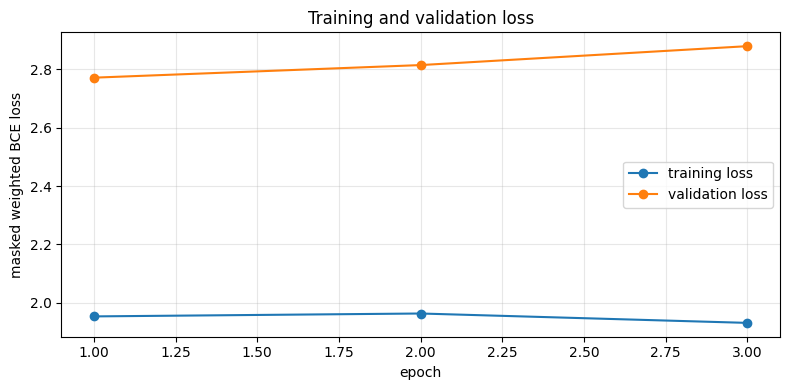

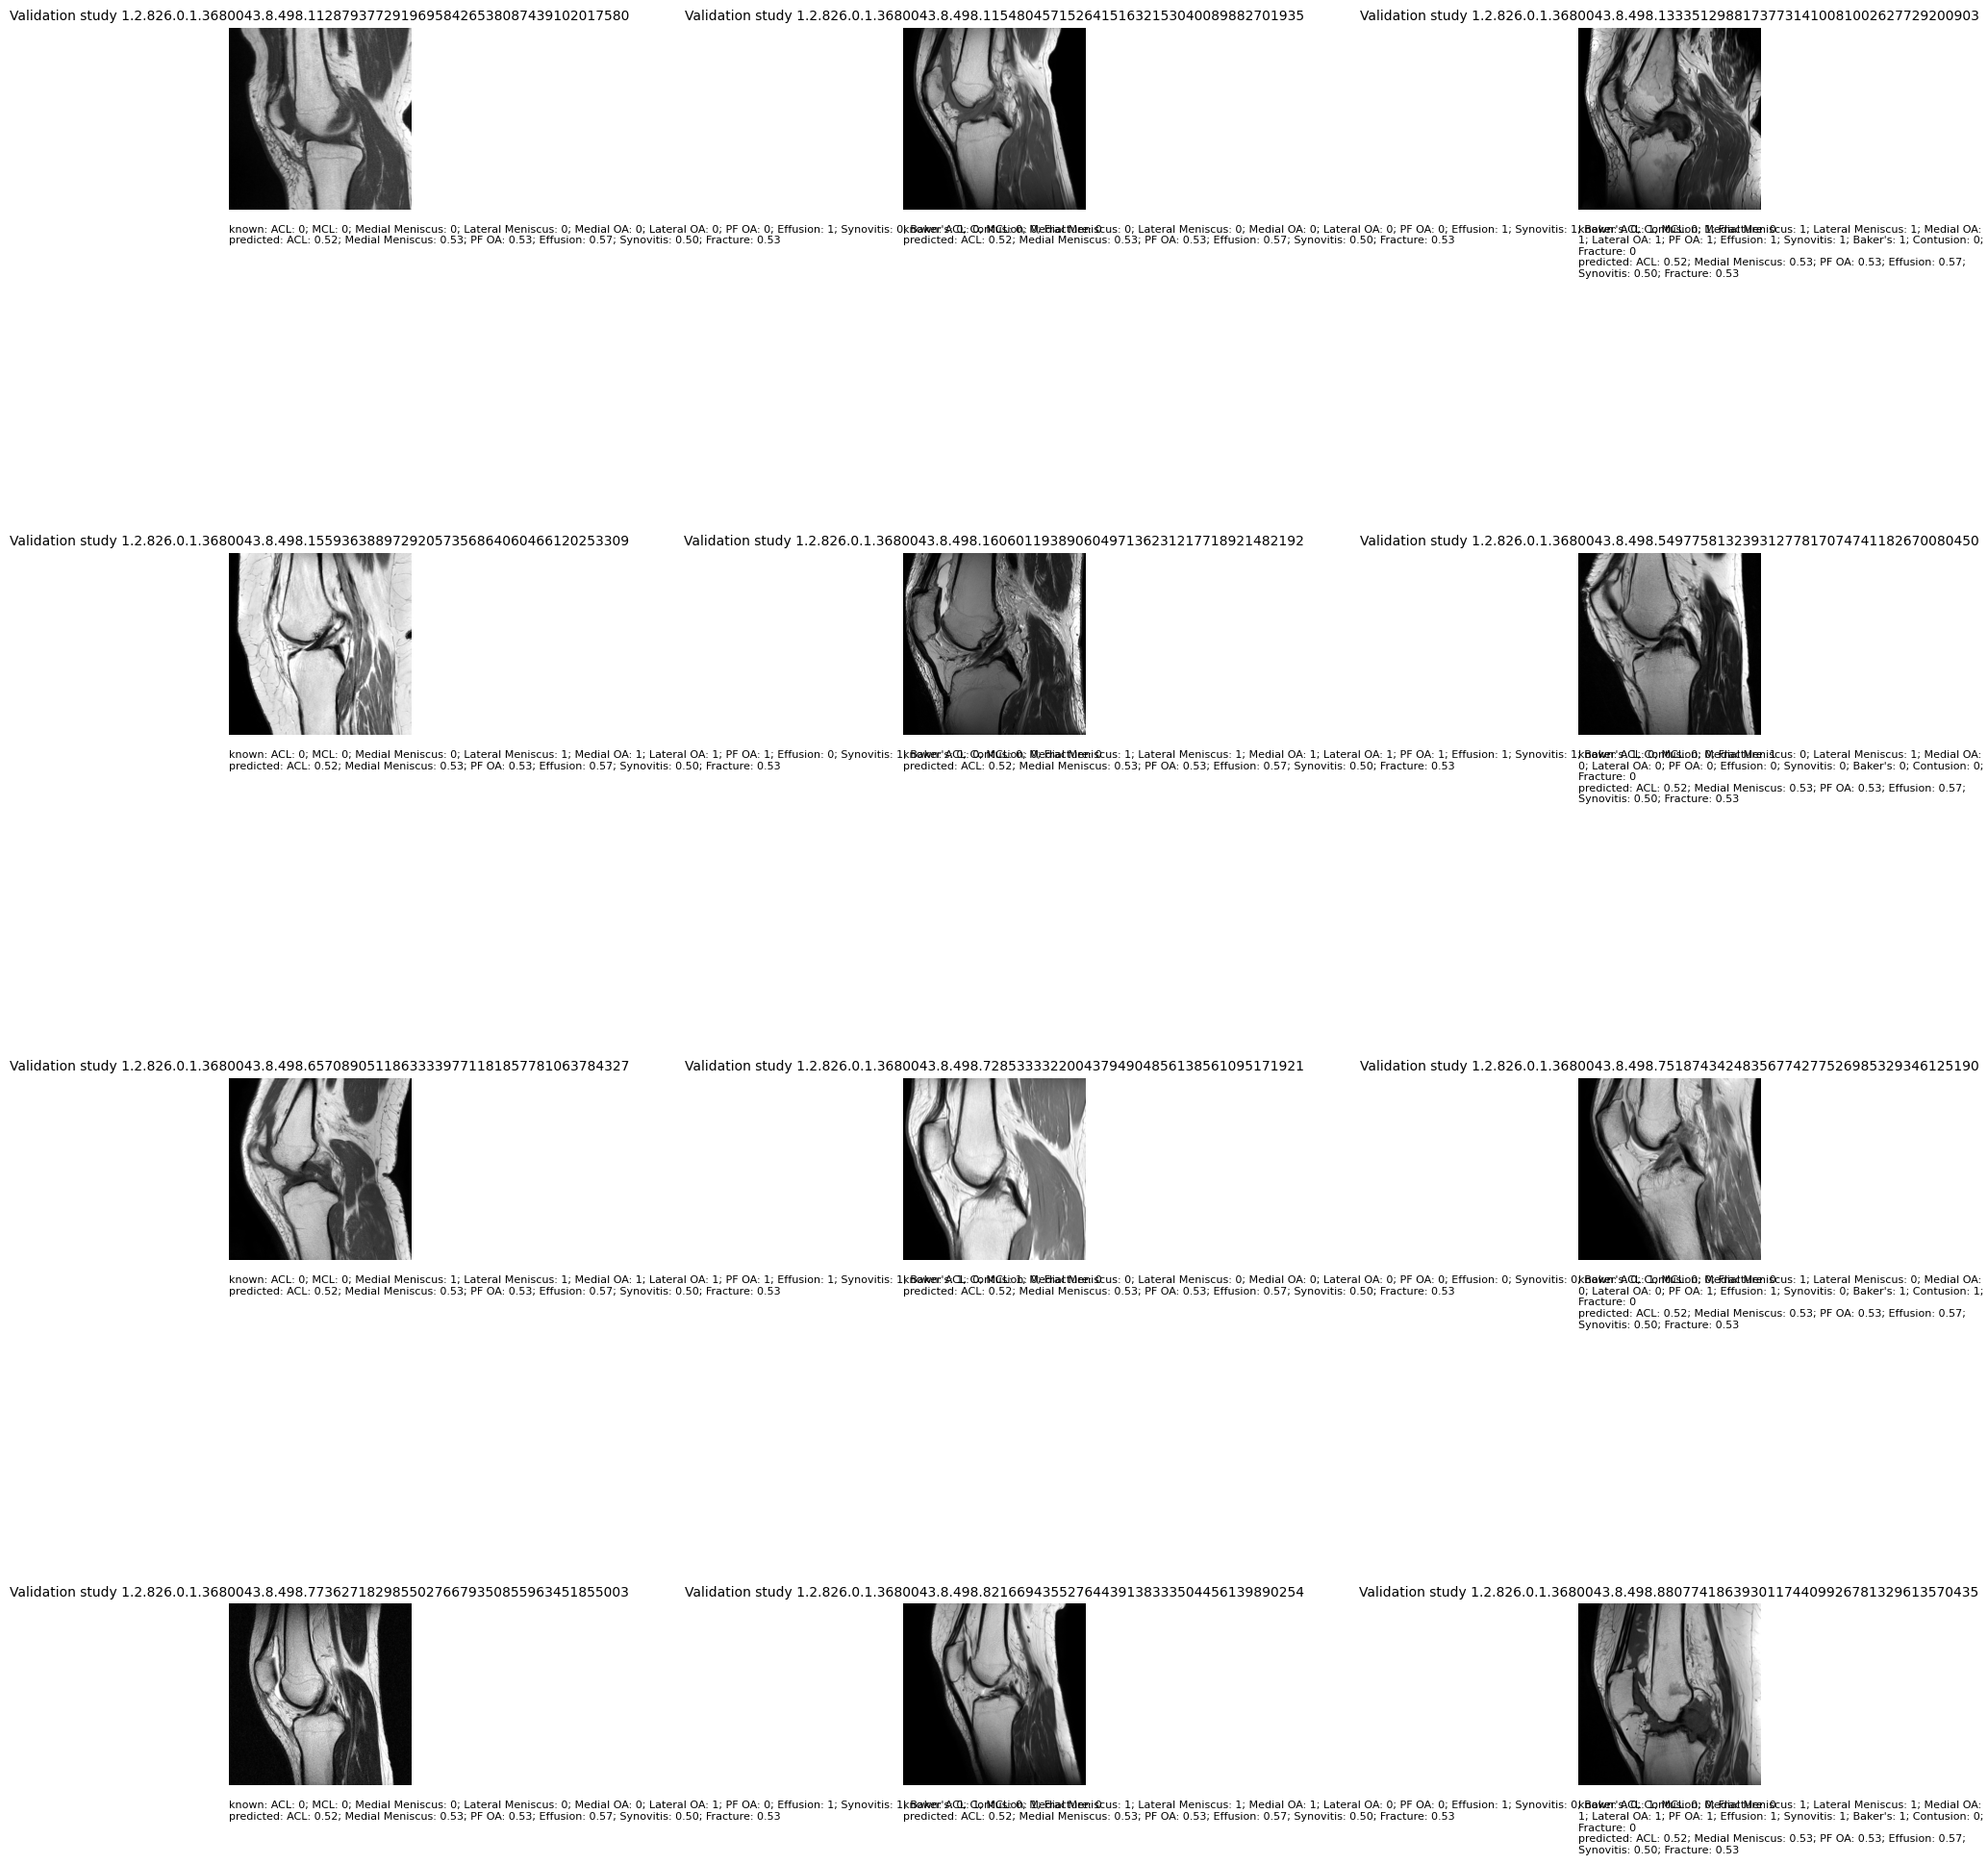

,StudyInstanceUID,known_labels,predicted_positive,max_probability
0,1.2.826.0.1.3680043.8.498.11287937729196958426...,ACL: 0; MCL: 0; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572289
1,1.2.826.0.1.3680043.8.498.11548045715264151632...,ACL: 0; MCL: 0; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572289
2,1.2.826.0.1.3680043.8.498.13335129881737731410...,ACL: 1; MCL: 0; Medial Meniscus: 1; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572287
3,1.2.826.0.1.3680043.8.498.15593638897292057356...,ACL: 0; MCL: 0; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.571991
4,1.2.826.0.1.3680043.8.498.16060119389060497136...,ACL: 0; MCL: 0; Medial Meniscus: 1; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572407
5,1.2.826.0.1.3680043.8.498.54977581323931277817...,ACL: 0; MCL: 0; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572285
6,1.2.826.0.1.3680043.8.498.65708905118633339771...,ACL: 0; MCL: 0; Medial Meniscus: 1; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572229
7,1.2.826.0.1.3680043.8.498.72853333220043794904...,ACL: 0; MCL: 1; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572168
8,1.2.826.0.1.3680043.8.498.75187434248356774277...,ACL: 1; MCL: 0; Medial Meniscus: 1; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572288
9,1.2.826.0.1.3680043.8.498.77362718298550276679...,ACL: 0; MCL: 0; Medial Meniscus: 0; Lateral Me...,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572287


,epoch,train_loss,validation_loss,validation_mean_auc,validation_known_cells,elapsed_seconds
0,1,1.953455,2.771453,0.488381,144,302.8
1,2,1.963374,2.814602,0.619542,144,301.2
2,3,1.931231,2.879381,0.668453,144,306.0


{
  "test_studies": 3,
  "test_series_rows": 15,
  "test_recognized_plane_series": 15,
  "test_data_root": "/content/knee_mri_subset"
}
test studies=3
Generated predictions for 3 test studies


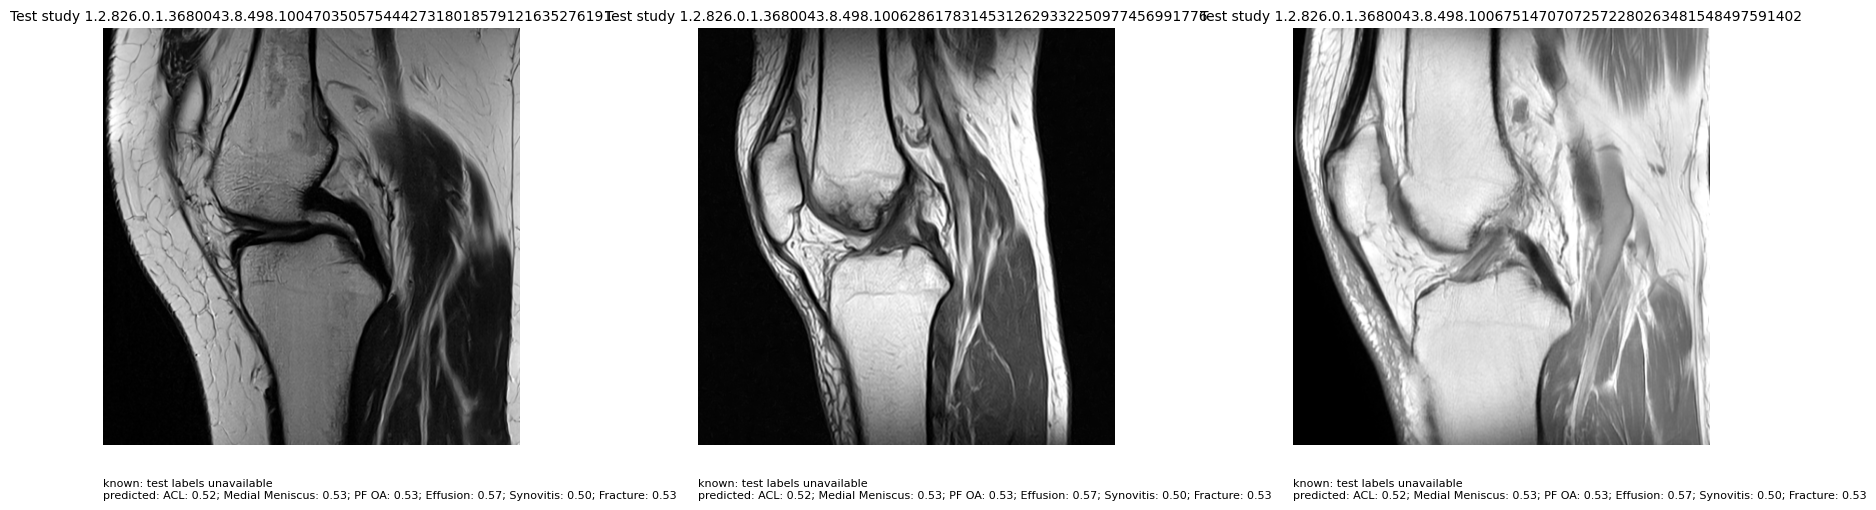

,StudyInstanceUID,known_labels,predicted_positive,max_probability
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,test labels unavailable,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572228
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,test labels unavailable,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572405
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,test labels unavailable,ACL: 0.52; Medial Meniscus: 0.53; PF OA: 0.53;...,0.572227


Saved new run to: /content/drive/MyDrive/knee_mri_subset_outputs/standalone_sparse_mil


In [13]:
# Keep training off until the preflight cell prints PASS.
RUN_TRAINING = True

# Run training only when the user intentionally enables it.
if RUN_TRAINING:
    # Train for CONFIG.epochs and collect history rows.
    HISTORY = train_model(EXPERIMENT)
    # Plot the training and validation loss curves.
    plot_loss_history(EXPERIMENT)
    # Plot up to twelve labelled validation MRI examples and their classifications.
    VALIDATION_CASE_TABLE = show_case_examples(EXPERIMENT, max_cases=12, title_prefix="Validation")
    # Display the numeric epoch history table.
    RESULTS = show_results(EXPERIMENT)
    # Build a local-DICOM loader for the separately extracted test subset.
    TEST_LOADER = build_test_loader(TEST_PATHS, CONFIG)
    # Generate one probability row and thresholded classification summary per test study.
    TEST_PREDICTIONS = predict_test_set(EXPERIMENT, TEST_LOADER)
    # Plot up to twelve unlabelled test MRI examples with their classifications.
    TEST_CASE_TABLE = show_case_examples(
        EXPERIMENT, loader=TEST_LOADER, max_cases=12, title_prefix="Test"
    )
    # Save this newly trained model, history, configuration, and test predictions to Drive.
    RUN_DIRECTORY = save_results(EXPERIMENT, test_predictions=TEST_PREDICTIONS)

## Memory controls

The defaults are deliberately safe for online DICOM loading. If the preflight
runs out of memory, change only one setting at a time and rerun the preflight:

1. Reduce `max_series_per_study` from `6` to `4`.
2. Reduce `encoder_chunk_size` from `2` to `1`.
3. Keep `image_size=448` unchanged unless you intentionally want a different
   image representation.

If the preflight passes comfortably, you may set `max_series_per_study=0` to
retain every recognized-plane series. Recreate `EXPERIMENT` after changing
`CONFIG`, then run preflight again.